# Bölüm 11: Deep Neural Networks (Derin Sinir Ağları) Eğitimi

> **Kaynak:** Hands-On Machine Learning with Scikit-Learn and PyTorch — Chapter 11  
> **Açıklama:** Bu notebook kitabın 11. bölümündeki tüm konuları Türkçe açıklamalarla, teknik İngilizce terimlerini ön planda tutarak kapsar.

---

## 📌 Bölüm İçeriği

1. Vanishing / Exploding Gradients (Kaybolan / Patlayan Gradyanlar)
2. Glorot & He Initialization (Ağırlık Başlatma Yöntemleri)
3. Activation Functions (Aktivasyon Fonksiyonları): ReLU, Leaky ReLU, ELU, SELU, GELU, Swish, Mish
4. Batch Normalization (Toplu Normalizasyon)
5. Layer Normalization (Katman Normalizasyonu)
6. Gradient Clipping (Gradyan Kırpma)
7. Transfer Learning (Transfer Öğrenme) ve Unsupervised Pretraining (Denetimsiz Ön Eğitim)
8. Optimizers (Optimizatörler): SGD, Momentum, NAG, AdaGrad, RMSProp, Adam, AdaMax, NAdam, AdamW
9. Learning Rate Scheduling (Öğrenme Hızı Zamanlama)
10. Regularization (Düzenlileştirme): L1/L2, Dropout, MC Dropout, Max-Norm


## Donanım Hızlandırıcısı (Hardware Accelerator) Seçimi

Derin sinir ağlarını eğitmek **çok yavaş** olabilir. Bu nedenle mevcut donanım hızlandırıcısını kontrol ediyoruz:

1. **CUDA (NVIDIA GPU)**: En yaygın ve hızlı seçenek. `torch.cuda.is_available()` ile kontrol edilir.
2. **MPS (Apple Silicon GPU)**: M1/M2/M3 çipli Mac'ler için. `torch.backends.mps.is_available()` ile kontrol edilir.
3. **CPU**: Hiçbiri yoksa CPU kullanılır (çok yavaş olabilir).

`device` değişkeni sonraki tüm tensor/model operasyonlarında kullanılacaktır.

In [17]:
# Sırayla hızlandırıcıları kontrol et: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = "cuda"   # NVIDIA GPU var
elif torch.backends.mps.is_available():
    device = "mps"    # Apple Silicon GPU var
else:
    device = "cpu"    # GPU yok, CPU kullan

print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: mps


##  GPU Uyarısı

CPU ile çalışıyorsa kullanıcıyı uyarıyoruz. GPU kullanımı için:
- **Google Colab**: Runtime > Change runtime type > GPU seçin
- **Kaggle**: Settings > Accelerator > GPU seçin

In [18]:
if device == "cpu":
    print("⚠️ Sinir ağları donanım hızlandırıcısı olmadan çok yavaş çalışabilir!")
    if IS_COLAB:
        print("Colab: Runtime > Change runtime > GPU donanım hızlandırıcısı seçin.")
    if IS_KAGGLE:
        print("Kaggle: Settings > Accelerator > GPU seçin.")

##  Matplotlib Görsel Ayarları

**Matplotlib** ile oluşturulan grafiklerin okunabilirliğini artırmak için global font boyutlarını ayarlıyoruz:

- `plt.rc('font', size=14)`: Tüm yazılar için temel boyut (14pt)
- `plt.rc('axes', labelsize=14, titlesize=14)`: Eksen etiketleri ve başlık boyutu
- `plt.rc('legend', fontsize=14)`: Açıklama kutusu yazı boyutu
- `plt.rc('xtick', labelsize=10)` / `plt.rc('ytick', labelsize=10)`: Eksen işaret etiketleri

In [19]:
import matplotlib.pyplot as plt

# Grafiklerin okunabilirliği için global font ayarları
plt.rc('font', size=14)                     # Genel yazı boyutu: 14pt
plt.rc('axes', labelsize=14, titlesize=14)  # Eksen etiket ve başlık boyutu
plt.rc('legend', fontsize=14)               # Legend (açıklama) yazı boyutu
plt.rc('xtick', labelsize=10)               # X ekseni işaret boyutu
plt.rc('ytick', labelsize=10)               # Y ekseni işaret boyutu

---
## 1. Vanishing / Exploding Gradients (Kaybolan / Patlayan Gradyanlar)

**Backpropagation** (geri yayılım) algoritması, çıktı katmanından başlayıp giriş katmanına doğru **gradient** (gradyan) bilgisini taşır. Bu süreçte iki kritik sorun ortaya çıkabilir:

### Vanishing Gradients (Kaybolan Gradyanlar)
Gradyanlar alt katmanlara ilerledikçe giderek küçülür. Alt katmanlar neredeyse hiç güncellenmez, model **convergence** (yakınsama) sağlayamaz.

### Exploding Gradients (Patlayan Gradyanlar)
Gradyanlar ilerledikçe büyür, ağırlıklar çok büyük miktarlarda güncellenir ve model **diverge** (ıraksama) eder. Özellikle **recurrent neural networks** (yinelemeli sinir ağları) bu soruna sıkça maruz kalır.

### Neden Oluşur?
2010 yılında Xavier Glorot ve Yoshua Bengio yaptıkları araştırmada, sorunun iki ana kaynağını tespit etti:
- **Sigmoid** aktivasyon fonksiyonunun kullanımı (0 veya 1'de doyuma ulaşır → türev ≈ 0)
- Kötü **weight initialization** (ağırlık başlatma): mean=0, std=1 olan normal dağılım

**Sigmoid** fonksiyonu büyük veya küçük giriş değerlerinde düzleşir, türevi sıfıra yaklaşır. Backpropagation bu noktadan itibaren neredeyse hiç gradyan taşıyamaz.

### Neden Sigmoid Sorunludur?
Sigmoid fonksiyonu: σ(z) = 1 / (1 + e^(-z))

- Çıkışı [0, 1] aralığındadır (ortalaması 0 değil!)
- Türevi maksimum **0.25**'tir (z=0'da)
- Her katmanda gradyan en az 4'te 1'e küçülür
- 10 katman için: 0.25^10 ≈ 0.000001 → Gradyan yok olur!

Aşağıdaki kod Sigmoid fonksiyonunu görselleştirir ve **saturasyon** (doyma) bölgelerini gösterir:

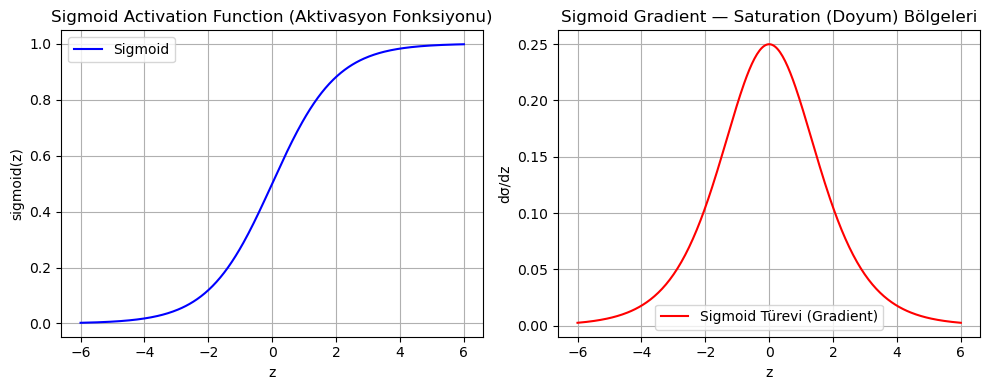

Giriş z=5 için sigmoid türevi: 0.017102
Doyum bölgesinde gradient neredeyse sıfır → Vanishing Gradient!


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Sigmoid doyum (saturation) görselleştirmesi
z = torch.linspace(-6, 6, 300)
sigmoid = torch.sigmoid(z)
sigmoid_grad = sigmoid * (1 - sigmoid)  # türev

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(z.numpy(), sigmoid.numpy(), label='Sigmoid', color='blue')
plt.title('Sigmoid Activation Function (Aktivasyon Fonksiyonu)')
plt.xlabel('z'); plt.ylabel('sigmoid(z)'); plt.grid(True); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(z.numpy(), sigmoid_grad.numpy(), label='Sigmoid Türevi (Gradient)', color='red')
plt.title('Sigmoid Gradient — Saturation (Doyum) Bölgeleri')
plt.xlabel('z'); plt.ylabel('dσ/dz'); plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

print("Giriş z=5 için sigmoid türevi:", round(float(sigmoid_grad[250]), 6))
print("Doyum bölgesinde gradient neredeyse sıfır → Vanishing Gradient!")

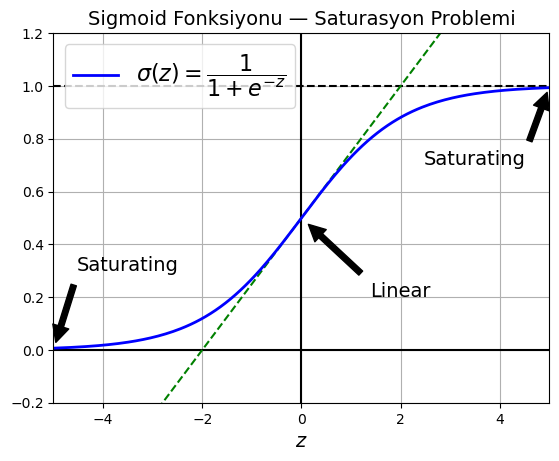

In [20]:
import numpy as np

# Sigmoid aktivasyon fonksiyonu: σ(z) = 1 / (1 + e^(-z))
# Çıkış her zaman (0, 1) aralığında
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# -5 ile 5 arasında 200 nokta oluştur
z = np.linspace(-5, 5, 200)

# Yatay referans çizgileri (y=0 ve y=1)
plt.plot([-5, 5], [0, 0], 'k-')   # y=0 çizgisi
plt.plot([-5, 5], [1, 1], 'k--')  # y=1 çizgisi (asymptote)

# Dikey referans çizgisi (z=0)
plt.plot([0, 0], [-0.2, 1.2], 'k-')

# Merkezdeki doğrusal bölgeyi gösteren eğri
# Sigmoid'in türevi z=0'da maks. (≈0.25)
plt.plot([-5, 5], [-3/4, 7/4], 'g--')

# Sigmoid eğrisini çiz
plt.plot(z, sigmoid(z), "b-", linewidth=2,
         label=r"$\sigma(z) = \dfrac{1}{1+e^{-z}}$")

# Ok stili (annotate için)
props = dict(facecolor='black', shrink=0.1)

# Sağ taraftaki saturasyon bölgesini işaretle (z > 3: fonksiyon ≈1'de sabit kalır)
plt.annotate('Saturating', xytext=(3.5, 0.7), xy=(5, 1), arrowprops=props,
             fontsize=14, ha="center")

# Sol taraftaki saturasyon bölgesini işaretle (z < -3: fonksiyon ≈0'da sabit kalır)
plt.annotate('Saturating', xytext=(-3.5, 0.3), xy=(-5, 0), arrowprops=props,
             fontsize=14, ha="center")

# Doğrusal bölgeyi işaretle (z ≈ 0: gradyan maksimum)
plt.annotate('Linear', xytext=(2, 0.2), xy=(0, 0.5), arrowprops=props,
             fontsize=14, ha="center")

plt.grid(True)
plt.axis([-5, 5, -0.2, 1.2])
plt.xlabel("$z$")
plt.legend(loc="upper left", fontsize=16)
plt.title("Sigmoid Fonksiyonu — Saturasyon Problemi")
plt.show()

# Saturasyon: z çok büyük veya çok küçük olduğunda
# türev sıfıra yaklaşır → gradyan backpropagation'da kaybolur

---
## 2. Weight Initialization (Ağırlık Başlatma): Glorot ve He

Unstable gradient sorununu çözmek için sinyal hem **forward pass** (ileri geçiş) hem **backward pass** (geri geçiş) sırasında düzgün akmalıdır. Bu da her katmandaki çıktıların **variance** (varyans) değerinin girdilerinkiyle eşit tutulmasını gerektirir.

### Fan-in ve Fan-out
- **fan_in**: Bir nöronun aldığı bağlantı (giriş) sayısı
- **fan_out**: Bir nöronun çıkardığı bağlantı (çıkış) sayısı
- **fan_avg** = (fan_in + fan_out) / 2

### Glorot (Xavier) Initialization
- Sigmoid, tanh, softmax aktivasyon fonksiyonları için
- Normal dağılım: σ² = 1 / fan_avg
- Uniform dağılım: r = √(3 / fan_avg)

### He (Kaiming) Initialization
- ReLU ve türevleri için (Leaky ReLU, ELU, GELU, Swish, Mish)
- Normal dağılım: σ² = 2 / fan_in

### LeCun Initialization
- SELU aktivasyon fonksiyonu için
- Normal dağılım: σ² = 1 / fan_in

| Initialization | Activation Functions | σ² (Normal) |
|---|---|---|
| Xavier Glorot | None, tanh, sigmoid, softmax | 1 / fan_avg |
| Kaiming He | ReLU, Leaky ReLU, ELU, GELU, Swish, Mish | 2 / fan_in |
| Yann LeCun | SELU | 1 / fan_in |

In [2]:
import torch
import torch.nn as nn

# He (Kaiming) Initialization — PyTorch örneği
layer = nn.Linear(40, 10)

# Yöntem 1: Elle çarpım
layer.weight.data *= 6 ** 0.5  # Kaiming uniform için düzeltme
torch.zero_(layer.bias.data)  # bias'ları sıfırla

# Yöntem 2: Daha temiz — torch.nn.init modülü
nn.init.kaiming_uniform_(layer.weight)  # He initialization
nn.init.zeros_(layer.bias)              # bias = 0

print("He Initialization uygulandı.")
print(f"Weight std: {layer.weight.data.std():.4f}")

# Tüm modele He initialization uygulama
def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight)
        nn.init.zeros_(module.bias)

model = nn.Sequential(
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 1),  nn.ReLU()
)
model.apply(use_he_init)  # modelin tüm katmanlarına uygula
print("Tüm katmanlara He Initialization uygulandı.")

He Initialization uygulandı.
Weight std: 0.2182
Tüm katmanlara He Initialization uygulandı.


# Glorot ve He Initialization (Başlangıç Değeri Atama)

## Neden Önemli?

Ağırlıkların başlangıç değerleri eğitimin başarısını doğrudan etkiler:
- **Çok küçük başlangıç**: Sinyal katmanlar arası geçişte kaybolur (vanishing)
- **Çok büyük başlangıç**: Sinyal aşırı büyür ve saturasyon yaşanır (exploding)

## Glorot Initialization (Xavier Initialization)

Xavier Glorot (2010) tarafından önerilmiştir. Her katmanda varyansı sabit tutmayı hedefler:

$$W \sim \text{Uniform}\left[-\sqrt{\frac{6}{n_{in} + n_{out}}}, \sqrt{\frac{6}{n_{in} + n_{out}}}\right]$$

- **Uygun aktivasyonlar**: Sigmoid, Tanh, Softmax
- **PyTorch fonksiyonu**: `nn.init.xavier_uniform_()` veya `nn.init.xavier_normal_()`

## He Initialization (Kaiming Initialization)

Kaiming He (2015) tarafından önerilmiştir. **ReLU ve türevleri** için tasarlanmıştır:

$$W \sim \text{Normal}\left(0, \sqrt{\frac{2}{n_{in}}}\right)$$

- **Uygun aktivasyonlar**: ReLU, Leaky ReLU, ELU
- **PyTorch fonksiyonu**: `nn.init.kaiming_uniform_()` veya `nn.init.kaiming_normal_()`

## LeCun Initialization

**SELU** aktivasyonu için tasarlanmıştır:
$$W \sim \text{Normal}\left(0, \sqrt{\frac{1}{n_{in}}}\right)$$

PyTorch'ta `nn.init.kaiming_normal_(mode='fan_in')` ile elde edilir.

In [21]:
import torch
import torch.nn as nn

# --- Yöntem 1: Manuel olarak ağırlıkları ölçeklendirme ---
# nn.Linear(40, 10): 40 giriş → 10 çıkış nöronlu tam bağlı katman
# Varsayılan başlangıç: Kaiming Uniform (PyTorch'un kendi defaultu)
layer = nn.Linear(40, 10)

# Ağırlıkları manuel olarak ölçeklendir:
# 6**0.5 = sqrt(6): Glorot/Xavier uniform için ölçek faktörü
# Kaiming için sqrt(6), LeCun için sqrt(3) kullanılır
layer.weight.data *= 6 ** 0.5  # Kaiming init (veya LeCun için 3**0.5)

# Bias'ları sıfırla: Başlangıçta bias sıfır olmalı
# torch.zero_(): in-place (yerinde) sıfırlama → aynı tensor'ı döndürür
torch.zero_(layer.bias.data)

print("Bias sıfırlandı:", layer.bias.data)

Bias sıfırlandı: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [22]:
# --- Yöntem 2: PyTorch'un built-in initialization fonksiyonları ---
layer = nn.Linear(40, 10)

# nn.init.kaiming_uniform_(): He Initialization (Uniform dağılım)
# Underscore (_) suffix: in-place operasyon (verinin üzerinde değişiklik yapar)
# Varsayılan: mode='fan_in', nonlinearity='leaky_relu'
nn.init.kaiming_uniform_(layer.weight)

# nn.init.zeros_(): Tüm elemanları sıfır yap
nn.init.zeros_(layer.bias)

# layer.bias: Parameter nesnesi (requires_grad=True ile)
print(layer.bias)  # Parameter containing: tensor([0., 0., ...], requires_grad=True)

Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)


In [23]:
# --- Yöntem 3: Modelin tüm katmanlarına initialization uygulama ---

# He initialization uygulayan fonksiyon
def use_he_init(module):
    """Bir modül Linear ise He initialization uygula."""
    if isinstance(module, nn.Linear):  # Sadece Linear katmanlara uygula
        nn.init.kaiming_uniform_(module.weight)  # Ağırlıklar: He/Kaiming Uniform
        nn.init.zeros_(module.bias)              # Bias: Sıfır

# nn.Sequential: Katmanları sırayla uygulayan konteyner
model = nn.Sequential(
    nn.Linear(50, 40),   # 50 → 40 nöron
    nn.ReLU(),           # Aktivasyon fonksiyonu
    nn.Linear(40, 1),    # 40 → 1 nöron (çıkış)
    nn.ReLU()
)

# model.apply(fn): Modelin tüm alt modüllerine fn fonksiyonunu uygular
# Recursive olarak çalışır: önce alt modüller, sonra parent modül
model.apply(use_he_init)

print(model)

Sequential(
  (0): Linear(in_features=50, out_features=40, bias=True)
  (1): ReLU()
  (2): Linear(in_features=40, out_features=1, bias=True)
  (3): ReLU()
)


In [24]:
# --- Leaky ReLU ile He Initialization ---
# Leaky ReLU'nun negative_slope parametresi init'i etkiler
model = nn.Sequential(
    nn.Linear(50, 40),
    nn.LeakyReLU(negative_slope=0.2)  # Negatif eğim = 0.2
)
model.apply(use_he_init)
print(model)

Sequential(
  (0): Linear(in_features=50, out_features=40, bias=True)
  (1): LeakyReLU(negative_slope=0.2)
)



## 3. Activation Functions (Aktivasyon Fonksiyonları)

Derin ağlardaki unstable gradient sorununu azaltmak için ReLU ve türevleri sigmoid'in yerini almıştır.

### 3.1 ReLU (Rectified Linear Unit)
- f(z) = max(0, z)
- Pozitif değerlerde doyuma uğramaz, hızlı hesaplanır
- **Dying ReLU problem**: Ağırlıklar yanlış güncelleniyor ise nöron sürekli sıfır üretir ve "ölür"

### 3.2 Leaky ReLU
- f(z) = max(αz, z) — negatif bölgede küçük eğim (α)
- **Dying ReLU** sorununu çözer, nöronlar hiç ölmez
- **RReLU** (Randomized Leaky ReLU): α eğitimde rastgele seçilir → regularizer etkisi
- **PReLU** (Parametric Leaky ReLU): α backpropagation ile öğrenilir

### 3.3 ELU (Exponential Linear Unit)
- z ≥ 0 ise: f(z) = z
- z < 0 ise: f(z) = α(exp(z) − 1)
- Dying ReLU yok, smooth fonksiyon, negatif çıktılar ortalamayı 0'a yaklaştırır
- Dezavantaj: exp() hesabı yavaştır

### 3.4 SELU (Scaled ELU)
- ELU'nun ~1.05 ölçeklendirilmiş versiyonu (α ≈ 1.67)
- **Self-normalizing** özelliği: her katmanın çıktısı mean=0, std=1'e yakınsama eğilimindedir
- **Koşullar:** Sadece dense layer stack, LeCun initialization, standartlaştırılmış input

### 3.5 GELU (Gaussian Error Linear Unit)
- GELU(z) = z × Φ(z)   [Φ: Gaussian CDF]
- Smooth, modern transformer mimarilerinde (BERT, GPT) kullanılır

### 3.6 Swish
- Swish(z) = z × σ(z)
- Google'ın NAS ile bulduğu aktivasyon, birçok görevde ReLU'yu geçer
- PyTorch'ta: `nn.SiLU`

### 3.7 Mish
- Mish(z) = z × tanh(softplus(z))
- Swish'e benzer performans, smooth

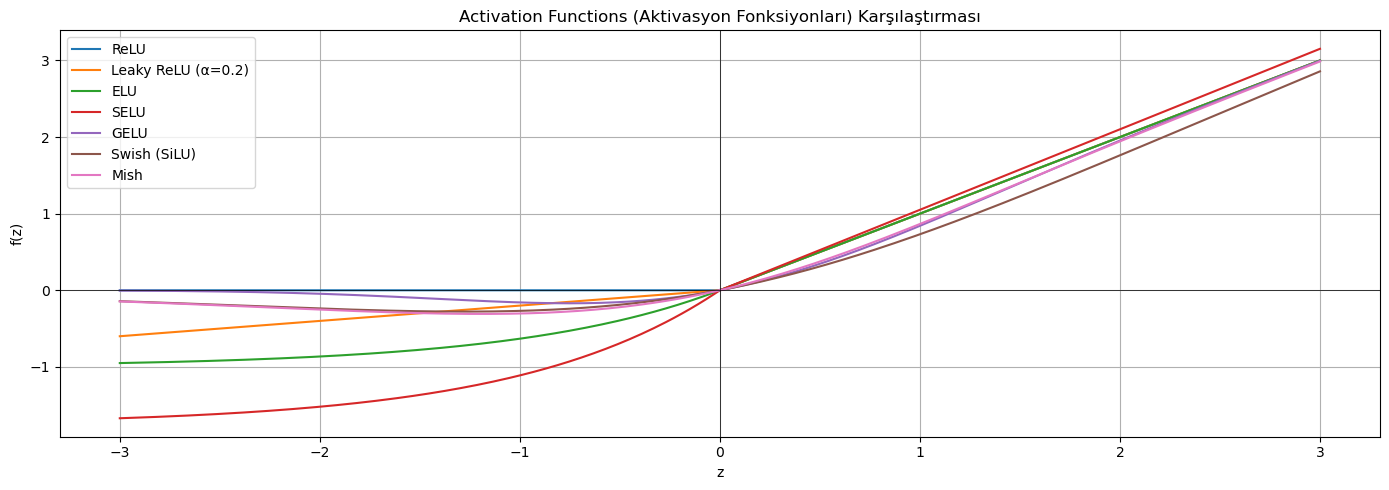

Leaky ReLU modeli He initialization ile oluşturuldu.


In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

z = torch.linspace(-3, 3, 300)

relu     = nn.ReLU()(z)
leaky    = nn.LeakyReLU(0.2)(z)
elu      = nn.ELU()(z)
selu     = nn.SELU()(z)
gelu     = nn.GELU()(z)
swish    = nn.SiLU()(z)      # Swish = SiLU
mish     = nn.Mish()(z)

plt.figure(figsize=(14, 5))
for i, (name, vals) in enumerate([
    ('ReLU', relu), ('Leaky ReLU (α=0.2)', leaky),
    ('ELU', elu),   ('SELU', selu),
    ('GELU', gelu), ('Swish (SiLU)', swish), ('Mish', mish)
]):
    plt.plot(z.numpy(), vals.detach().numpy(), label=name)

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Activation Functions (Aktivasyon Fonksiyonları) Karşılaştırması')
plt.xlabel('z'); plt.ylabel('f(z)')
plt.legend(loc='upper left'); plt.grid(True)
plt.tight_layout()
plt.show()

# PyTorch kullanımı
alpha = 0.2
model = nn.Sequential(
    nn.Linear(50, 40),
    nn.LeakyReLU(negative_slope=alpha)
)
nn.init.kaiming_uniform_(model[0].weight, alpha, nonlinearity="leaky_relu")
print("Leaky ReLU modeli He initialization ile oluşturuldu.")

## Daha İyi Aktivasyon Fonksiyonları (Better Activation Functions)

Geleneksel Sigmoid ve Tanh yerine kullanılabilecek modern aktivasyon fonksiyonları.

### 1.Leaky ReLU

**ReLU (Rectified Linear Unit)** problemi: z < 0 için çıkış her zaman 0'dır → **Dying ReLU** problemi (nöronlar ölü kalabilir, hiç aktive olmaz).

**Leaky ReLU** çözümü: Negatif değerler için küçük ama sıfır olmayan bir eğim (α) kullanır:

$$\text{LeakyReLU}(z) = \max(\alpha z, z) = \begin{cases} z & \text{if } z > 0 \\ \alpha z & \text{if } z \leq 0 \end{cases}$$

- α = 0 ise: Standart ReLU
- α = 0.01 ise: Leaky ReLU (yaygın değer)
- α = 0.2 ise: Daha fazla sızdırma

**Avantajlar:**
- Dying ReLU problemini önler
- Tüm z değerleri için gradyan sıfır değil
- Basit ve hesaplamak kolay

**PyTorch**: `nn.LeakyReLU(negative_slope=alpha)`

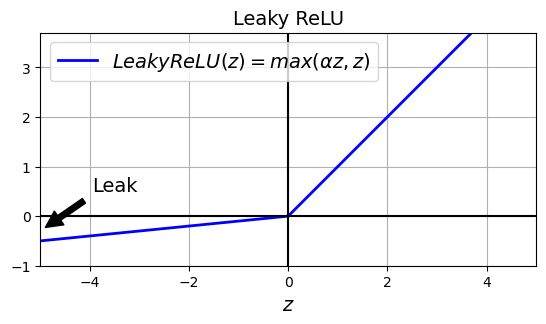

In [25]:
# Leaky ReLU fonksiyonunu manuel olarak tanımla ve görselleştir
def leaky_relu(z, alpha):
    """Leaky ReLU: z>0 için z, z<=0 için alpha*z döndürür."""
    # np.maximum(a, b): element-wise maksimum
    return np.maximum(alpha * z, z)

z = np.linspace(-5, 5, 200)

# alpha=0.1: Negatif bölgedeki eğim (Leak)
plt.plot(z, leaky_relu(z, 0.1), "b-", linewidth=2,
         label=r"$LeakyReLU(z) = max(\alpha z, z)$")
plt.plot([-5, 5], [0, 0], 'k-')  # y=0 referans çizgisi
plt.plot([0, 0], [-1, 3.7], 'k-')  # z=0 referans çizgisi
plt.grid(True)

props = dict(facecolor='black', shrink=0.1)
# 'Leak' etiketi: Negatif bölgedeki küçük eğimi gösterir
plt.annotate('Leak', xytext=(-3.5, 0.5), xy=(-5, -0.3), arrowprops=props,
             fontsize=14, ha="center")

plt.xlabel("$z$")
plt.axis([-5, 5, -1, 3.7])
plt.gca().set_aspect("equal")  # Eşit ölçek: x ve y birimleri eşit
plt.legend()
plt.title("Leaky ReLU")
plt.show()

In [26]:
# PyTorch ile Leaky ReLU modeli oluşturma
torch.manual_seed(42)  # Reproducibility için sabit seed

alpha = 0.2  # Negatif eğim parametresi
model = nn.Sequential(
    nn.Linear(50, 40),               # 50 giriş → 40 nöron
    nn.LeakyReLU(negative_slope=alpha)  # Leaky ReLU aktivasyon
)

# He initialization uygula — Leaky ReLU için alpha da belirtilmeli!
# kaiming_uniform_ için nonlinearity parametresi 'leaky_relu' olmalı
nn.init.kaiming_uniform_(model[0].weight, alpha, nonlinearity="leaky_relu")

# Test: 2 adet 50-boyutlu random input geçir
# torch.rand(2, 50): [0,1] arasında uniform dağılımlı tensor
output = model(torch.rand(2, 50))
print("Çıkış şekli (shape):", output.shape)  # torch.Size([2, 40])

Çıkış şekli (shape): torch.Size([2, 40])


### 2.ELU (Exponential Linear Unit)

**ELU** negatif değerler için üstel (exponential) bir fonksiyon kullanır:

$$\text{ELU}(z) = \begin{cases} z & \text{if } z > 0 \\ \alpha(e^z - 1) & \text{if } z \leq 0 \end{cases}$$

**Leaky ReLU'ya göre avantajları:**
- Negatif değerler için **düzgün bir eğri** (smooth)
- Ortalama çıkış **sıfıra yakın** → Vanishing gradients azalır
- Gürültüye (noise) karşı daha sağlam

**Dezavantajı:**
- Hesaplama maliyeti daha yüksek (exp() fonksiyonu)

**PyTorch**: `nn.ELU(alpha=1.0)` (α varsayılan: 1.0)

In [27]:
# ELU aktivasyonlu model — Leaky ReLU ile aynı kolaylıkta kullanılır
torch.manual_seed(42)

model = nn.Sequential(
    nn.Linear(50, 40),  # Linear katman: 50 giriş, 40 çıkış
    nn.ELU()            # ELU aktivasyon (alpha varsayılan=1.0)
)

# He initialization: ELU de ReLU ailesi gibi davrandığından
# kaiming_uniform_ uygun bir seçimdir
nn.init.kaiming_uniform_(model[0].weight)

output = model(torch.rand(2, 50))
print("ELU çıkış şekli:", output.shape)

ELU çıkış şekli: torch.Size([2, 40])


## 3. SELU (Scaled Exponential Linear Unit)

**SELU** (Klambauer et al., 2017), **kendi kendini normalleştiren (self-normalizing)** bir aktivasyon fonksiyonudur:

$$\text{SELU}(z) = \lambda \cdot \begin{cases} z & \text{if } z > 0 \\ \alpha(e^z - 1) & \text{if } z \leq 0 \end{cases}$$

Özel değerler:
- λ ≈ **1.0507**
- α ≈ **1.6733**

**Kendi kendini normalleştirme**: SELU kullanan katmanın çıkışı otomatik olarak **ortalaması 0, varyansı 1** olan bir dağılıma yakınsar. Bu sayede Batch Normalization'a gerek kalmaz!

**Şartlar:**
- **LeCun initialization** kullanılmalı
- Girişler de normalleştirilmiş olmalı
- **AlphaDropout** (Dropout yerine) kullanılmalı
- Yalnızca **fully connected (Dense)** katmanlarda güvenilir (CNN'de daha az stabil)

**PyTorch**: `nn.SELU()`

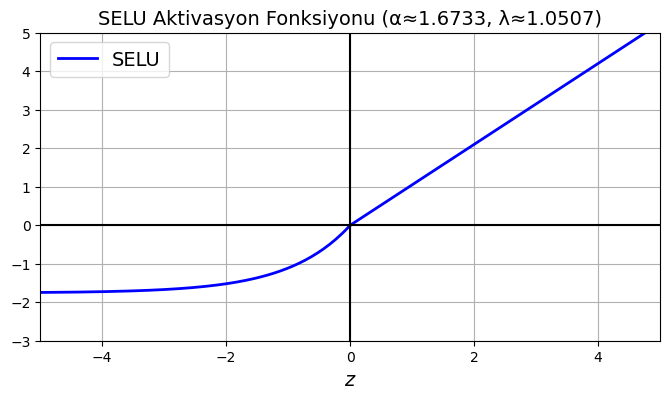

SELU alpha_0_1 ≈ 1.6733
SELU scale_0_1 ≈ 1.0507


In [28]:
# SELU aktivasyonunun şeklini görselleştiren kod
from scipy.special import erfc  # Tamamlayıcı hata fonksiyonu (erfc)

# SELU sabit değerleri (matematiksel olarak türetilmiş)
alpha_0_1 = -np.sqrt(2 / np.pi) / (erfc(1/np.sqrt(2)) * np.exp(1/2) - 1)
scale_0_1 = (1 - erfc(1 / np.sqrt(2)) * np.sqrt(np.e)) * np.sqrt(2 * np.pi) * (
    2 * erfc(np.sqrt(2)) * np.e**2 + np.pi * erfc(1/np.sqrt(2))**2 * np.e -
    2 * (2 + np.pi) * erfc(1/np.sqrt(2)) * np.sqrt(np.e) + np.pi +
    2)**(-1/2)

# SELU fonksiyonunu tanımla
def elu_plus_one_prime_zero(z, scale, alpha):  
    """SELU eğrisini hesaplar."""
    return scale * np.where(z >= 0, z, alpha * (np.exp(z) - 1))

z = np.linspace(-5, 5, 200)
# Standart SELU (PyTorch'un kullandığı)
SELU_values = elu_plus_one_prime_zero(z, scale=1.0507, alpha=1.6733)

plt.figure(figsize=(8, 4))
plt.plot(z, SELU_values, "b-", linewidth=2, label="SELU")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([0, 0], [-3, 5], 'k-')
plt.grid(True)
plt.xlabel("$z$")
plt.axis([-5, 5, -3, 5])
plt.legend()
plt.title("SELU Aktivasyon Fonksiyonu (α≈1.6733, λ≈1.0507)")
plt.show()
print(f"SELU alpha_0_1 ≈ {alpha_0_1:.4f}")
print(f"SELU scale_0_1 ≈ {scale_0_1:.4f}")

In [29]:
# SELU kullanımı — PyTorch'ta son derece basit
torch.manual_seed(42)

model = nn.Sequential(
    nn.Linear(50, 40),
    nn.SELU()  # Kendi kendini normalleştiren aktivasyon
)

# SELU için LeCun initialization gereklidir!
# kaiming_normal_ ile fan_in modu = LeCun initialization
nn.init.kaiming_normal_(model[0].weight, mode='fan_in')

output = model(torch.rand(2, 50))
print("SELU çıkış şekli:", output.shape)

SELU çıkış şekli: torch.Size([2, 40])


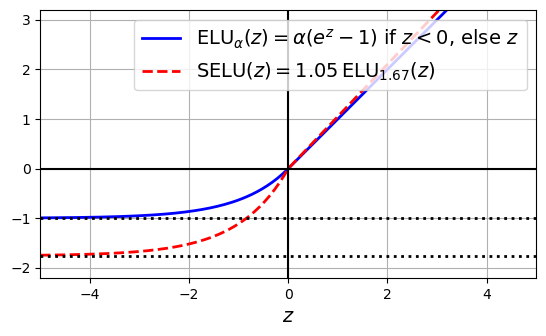

In [58]:
# extra code – this cell generates Figure 11–3

from scipy.special import erfc

# alpha and scale to self normalize with mean 0 and standard deviation 1
# (see equation 14 in the paper):
alpha_0_1 = -np.sqrt(2 / np.pi) / (erfc(1 / np.sqrt(2)) * np.exp(1 / 2) - 1)
scale_0_1 = (
    (1 - erfc(1 / np.sqrt(2)) * np.sqrt(np.e))
    * np.sqrt(2 * np.pi)
    * (
        2 * erfc(np.sqrt(2)) * np.e ** 2
        + np.pi * erfc(1 / np.sqrt(2)) ** 2 * np.e
        - 2 * (2 + np.pi) * erfc(1 / np.sqrt(2)) * np.sqrt(np.e)
        + np.pi
        + 2
    ) ** (-1 / 2)
)

def elu(z, alpha=1):
    return np.where(z < 0, alpha * (np.exp(z) - 1), z)

def selu(z, scale=scale_0_1, alpha=alpha_0_1):
    return scale * elu(z, alpha)

z = np.linspace(-5, 5, 200)
plt.plot(z, elu(z), "b-", linewidth=2, label=r"ELU$_\alpha(z) = \alpha (e^z - 1)$ if $z < 0$, else $z$")
plt.plot(z, selu(z), "r--", linewidth=2, label=r"SELU$(z) = 1.05 \, $ELU$_{1.67}(z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [-1, -1], 'k:', linewidth=2)
plt.plot([-5, 5], [-1.758, -1.758], 'k:', linewidth=2)
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-5, 5, -2.2, 3.2])
plt.xlabel("$z$")
plt.gca().set_aspect("equal")
plt.legend()

plt.show()

## 4. GELU, Swish, SwiGLU, Mish ve ReLU²

Modern derin öğrenme modellerinde (BERT, GPT) kullanılan yeni nesil aktivasyon fonksiyonları:

### GELU (Gaussian Error Linear Unit)
$$\text{GELU}(z) = z \cdot \Phi(z)$$
Φ(z): Standart normal kümülatif dağılım fonksiyonu. **BERT, GPT, T5** gibi büyük dil modellerinde kullanılır.

### Swish
$$\text{Swish}(z) = z \cdot \sigma(\beta z) = \frac{z}{1 + e^{-\beta z}}$$
- β = 0 ise: z/2 (linear)
- β → ∞ ise: ReLU
- β = 1 ise: Swish (yaygın kullanım)

### Mish
$$\text{Mish}(z) = z \cdot \tanh(\text{softplus}(z)) = z \cdot \tanh(\ln(1 + e^z))$$

### ReLU² (ReLU-squared)
$$\text{ReLU}^2(z) = \max(0, z)^2 = \text{ReLU}(z)^2$$

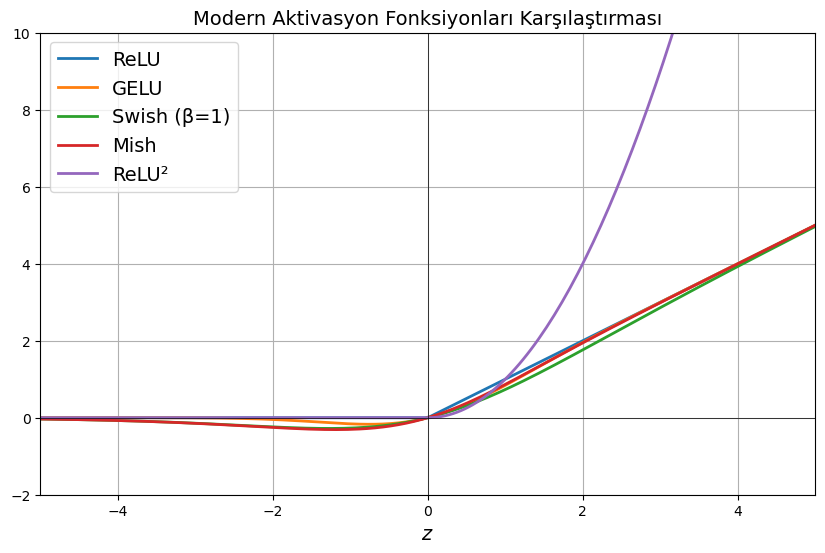

In [30]:
# GELU, Swish, Mish ve ReLU² görselleştirmesi
def swish(z, beta=1):
    """Swish: z * sigmoid(beta*z)"""
    return z * sigmoid(z * beta)  # sigmoid fonksiyonu yukarıda tanımlandı

z = np.linspace(-5, 5, 200)

# Birden fazla aktivasyon fonksiyonunu karşılaştır
activations = {
    "ReLU": np.maximum(0, z),                    # Standart ReLU: max(0, z)
    "GELU": z * 0.5 * (1 + np.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z**3))),  # GELU yaklaşımı
    "Swish (β=1)": swish(z, beta=1),             # Swish
    "Mish": z * np.tanh(np.log(1 + np.exp(z))), # Mish
    "ReLU²": np.maximum(0, z) ** 2,             # ReLU kare
}

plt.figure(figsize=(10, 6))
for name, values in activations.items():
    plt.plot(z, values, linewidth=2, label=name)

plt.plot([-5, 5], [0, 0], 'k-', linewidth=0.5)
plt.plot([0, 0], [-2, 10], 'k-', linewidth=0.5)
plt.grid(True)
plt.xlabel("$z$")
plt.axis([-5, 5, -2, 10])
plt.legend()
plt.title("Modern Aktivasyon Fonksiyonları Karşılaştırması")
plt.show()

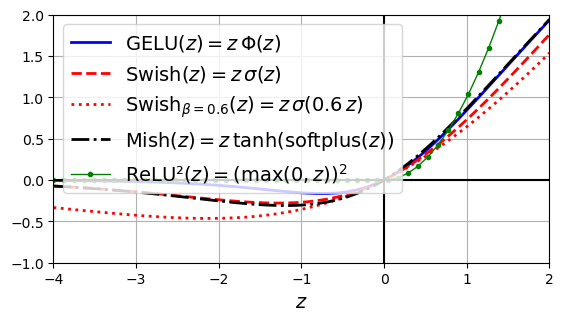

In [60]:


def swish(z, beta=1):
    return z * sigmoid(beta * z)

def approx_gelu(z):
    return swish(z, beta=1.702)

def softplus(z):
    return np.log(1 + np.exp(z))

def mish(z):
    return z * np.tanh(softplus(z))

def relu_squared(z):
    return np.maximum(0, z)**2

z = np.linspace(-4, 2, 50)

beta = 0.6
plt.plot(z, approx_gelu(z), "b-", linewidth=2,
         label=r"GELU$(z) = z\,\Phi(z)$")
plt.plot(z, swish(z), "r--", linewidth=2,
         label=r"Swish$(z) = z\,\sigma(z)$")
plt.plot(z, swish(z, beta), "r:", linewidth=2,
         label=fr"Swish$_{{\beta={beta}}}(z)=z\,\sigma({beta}\,z)$")
plt.plot(z, mish(z), "k-.", linewidth=2,
         label=fr"Mish$(z) = z\,\tanh($softplus$(z))$")
plt.plot(z, relu_squared(z), "g.-", linewidth=1,
         label=fr"ReLU²$(z) = (\max(0, z))^2$")
plt.plot([-4, 2], [0, 0], 'k-')
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-4, 2, -1, 2])
plt.gca().set_aspect("equal")
plt.xlabel("$z$")
plt.legend(loc="upper left")

plt.show()

### SwiGLU (Swish Gated Linear Unit)

**SwiGLU**, **Gated Linear Unit (GLU)** mimarisinin Swish aktivasyonlu versiyonudur. Özellikle **LLaMA, PaLM** gibi büyük dil modellerinde tercih edilir:

$$\text{SwiGLU}(x) = \text{Swish}(xW_1) \odot (xW_2)$$

- İki lineer dönüşüm kullanır: W1 ve W2
- ⊙: Element-wise çarpım (Hadamard product)
- Parametre kapısı (gate): Hangi bilginin geçeceğini öğrenir

In [31]:
# SwiGLU implementasyonu — özel nn.Module
class SwiGLU(nn.Module):
    """Swish Gated Linear Unit aktivasyon katmanı."""
    
    def __init__(self, beta=1.0):
        super().__init__()
        # beta: Swish'in ölçekleme parametresi
        # nn.Parameter: Eğitilebilir parametre (gradient hesaplanır)
        self.beta = nn.Parameter(torch.tensor(beta))
    
    def forward(self, X):
        """Forward pass: X'i iki yarıya böl ve SwiGLU uygula."""
        # X'i son boyut boyunca 2'ye böl
        # torch.chunk(tensor, n, dim): tensor'ı dim boyutunda n parçaya böler
        gate, output = torch.chunk(X, 2, dim=-1)
        
        # Swish(gate) * output
        # torch.sigmoid: Sigmoid fonksiyonu
        return output * gate * torch.sigmoid(self.beta * gate)

# Test
swiglu = SwiGLU(beta=1.0)
test_input = torch.randn(4, 100)  # 4 örnek, 100 özellik
output = swiglu(test_input)
print(f"SwiGLU giriş: {test_input.shape}")
print(f"SwiGLU çıkış: {output.shape}")  # Son boyut yarıya iner: 100 → 50

SwiGLU giriş: torch.Size([4, 100])
SwiGLU çıkış: torch.Size([4, 50])


### ReLU² (ReLU Squared)

**ReLU²**, standart ReLU'nun karesini alır:

$$\text{ReLU}^2(z) = \max(0, z)^2$$

- Pozitif değerleri **daha güçlü** vurgular
- Büyük aktivasyonlara daha fazla ağırlık verir

In [32]:
import torch.nn.functional as F

# ReLU² özel modülü
class ReLU2(nn.Module):
    """ReLU kare aktivasyon fonksiyonu: max(0, z)^2"""
    
    def forward(self, x):
        # F.relu(): Functional API'den ReLU (parametresiz)
        # ** 2: Kare alma
        return F.relu(x) ** 2

# Test
relu2 = ReLU2()
test = torch.tensor([-2.0, -0.5, 0.0, 0.5, 1.0, 2.0])
print("Giriş:", test)
print("ReLU²:", relu2(test))  # [-2→0, -0.5→0, 0→0, 0.5→0.25, 1→1, 2→4]

Giriş: tensor([-2.0000, -0.5000,  0.0000,  0.5000,  1.0000,  2.0000])
ReLU²: tensor([0.0000, 0.0000, 0.0000, 0.2500, 1.0000, 4.0000])


---
## 4. Batch Normalization (Toplu Normalizasyon — BN)

2015'te Ioffe ve Szegedy tarafından önerilen Batch Normalization, **internal covariate shift** (iç kovaryat kayması) sorununu azaltır: her katmana gelen girdilerin dağılımı eğitim boyunca sürekli değişir, BN bunu normalize eder.

### BN Algoritması (Eğitim Aşaması)
Mini-batch B üzerinde, her özellik için:

1. **μ_B** = mini-batch ortalaması
2. **σ²_B** = mini-batch varyansı  
3. **x̂(i)** = (x(i) − μ_B) / √(σ²_B + ε)  ← normalize et
4. **z(i)** = γ ⊗ x̂(i) + β  ← ölçekle ve kaydır

- **γ** (gamma): Öğrenilen ölçek parametresi (output scale)
- **β** (beta): Öğrenilen kayma parametresi (output offset / shift)
- **ε** (epsilon): Sıfıra bölmeyi önleyen smoothing term (~1e-5)

### Test/Inference Aşaması
Tek örnek için batch istatistiği hesaplanamaz. Bu yüzden eğitim boyunca **exponential moving average** (üstel hareketli ortalama) ile tahmini μ ve σ² depolanır; inference'ta bunlar kullanılır.

### BN'nin Faydaları
- Vanishing/Exploding gradient sorununu büyük ölçüde azaltır
- Ağırlık başlatmaya daha az duyarlı hale getirir
- Daha büyük **learning rate** (öğrenme hızı) kullanılabilir → daha hızlı eğitim
- Regularizer etkisi → dropout'a daha az ihtiyaç

### Önemli Uyarı
BN, eğitim (`model.train()`) ve değerlendirme (`model.eval()`) modlarında farklı davranır. Bunu unutmak en yaygın hatalardan biridir!


## Aktivasyon Sonrası mı, Öncesi mi?

**Orijinal makale**: Aktivasyon öncesi (BN → Activation)
**Pratikte**: İkisi de denenebilir, aktivasyon sonrası genellikle daha yaygın

## PyTorch Parametreleri

- **num_features**: Normalleştirilecek özellik sayısı
- **eps**: ε (sayısal kararlılık için)
- **momentum**: Çalışan ortalama için momentum
- **affine**: True ise γ ve β parametrelerini öğrenir
- **track_running_stats**: Test zamanı için istatistikleri takip eder

In [4]:
import torch
import torch.nn as nn

# Batch Normalization SONRA aktivasyon (önerilen standart yöntem)
model_bn_after = nn.Sequential(
    nn.Flatten(),
    nn.BatchNorm1d(1 * 28 * 28),      # giriş normalizasyonu
    nn.Linear(1 * 28 * 28, 300),
    nn.ReLU(),
    nn.BatchNorm1d(300),
    nn.Linear(300, 100),
    nn.ReLU(),
    nn.BatchNorm1d(100),
    nn.Linear(100, 10)
)

# Batch Normalization ÖNCE aktivasyon (orijinal makalenin önerisi)
model_bn_before = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1 * 28 * 28, 300, bias=False),  # BN zaten bias içerdiği için False
    nn.BatchNorm1d(300),
    nn.ReLU(),
    nn.Linear(300, 100, bias=False),
    nn.BatchNorm1d(100),
    nn.ReLU(),
    nn.Linear(100, 10)
)

# BN parametrelerine bakalım
print("BN katman parametreleri:", dict(model_bn_after[2].named_parameters()).keys())
print("BN katman buffer'ları:", dict(model_bn_after[2].named_buffers()).keys())
# weight = γ (scale), bias = β (shift)
# running_mean = μ tahmini, running_var = σ² tahmini

# ÖNEMLİ: Eğitim/evaluation mod geçişi
model_bn_after.train()   # eğitim modu — batch istatistiklerini kullanır
model_bn_after.eval()    # değerlendirme modu — running mean/var kullanır
print("\nEğitim için model.train(), inference için model.eval() çağrılmalı!")

BN katman parametreleri: dict_keys(['weight', 'bias'])
BN katman buffer'ları: dict_keys([])

Eğitim için model.train(), inference için model.eval() çağrılmalı!


---
## 5. Layer Normalization (Katman Normalizasyonu — LN)

**Layer Normalization**, Batch Normalization'a çok benzer, ancak batch boyutu yerine **feature dimensions** (özellik boyutları) üzerinde normalize eder.

### BN ile Farkları
| Özellik | Batch Normalization | Layer Normalization |
|---|---|---|
| Normalize ettiği boyut | Batch boyutu | Feature boyutu |
| Eğitim/test farkı | Farklı davranır | Aynı davranır |
| Küçük batch boyutu | Zayıf | İyi çalışır |
| RNN/Transformer | Zor uygulanır | Yaygın kullanım |

LN, her örneği bağımsız normalize ettiğinden eğitim ve test aşamasında aynı şekilde davranır. Bu nedenle **Transformers** (BERT, GPT vb.), **diffusion networks** ve recurrent ağlarda tercih edilir.

**LN Formülü:**
$$y = \frac{x - E[x]}{\sqrt{Var[x] + \epsilon}} \cdot \gamma + \beta$$

Her örnek için bağımsız olarak hesaplanır (batch boyutu 1 olsa bile çalışır).

**Kullanım alanları:**
- **Transformer** modelleri (BERT, GPT)
- **RNN/LSTM** ağları
- Küçük batch boyutlarında

**PyTorch**: `nn.LayerNorm(normalized_shape)`


In [5]:
import torch
import torch.nn as nn

# Layer Normalization örneği: RGB resim batch'i
inputs = torch.randn(32, 3, 100, 200)  # 32 resim, 3 kanal, 100x200

# Her kanalı ayrı normalize et (son 2 boyut)
layer_norm_per_channel = nn.LayerNorm([100, 200])
result1 = layer_norm_per_channel(inputs)  # [32, 3, 100, 200]

# Tüm kanallar birlikte normalize et (son 3 boyut)
layer_norm_all_channels = nn.LayerNorm([3, 100, 200])
result2 = layer_norm_all_channels(inputs)  # [32, 3, 100, 200]

print("Input şekli:", inputs.shape)
print("Kanal bazlı LN çıktısı:", result1.shape)
print("Tüm kanal LN çıktısı:", result2.shape)

# Manuel doğrulama
means = inputs.mean(dim=[2, 3], keepdim=True)
vars_ = inputs.var(dim=[2, 3], keepdim=True, unbiased=False)
stds  = torch.sqrt(vars_ + layer_norm_per_channel.eps)
result_manual = layer_norm_per_channel.weight * (inputs - means) / stds + layer_norm_per_channel.bias
print("\nManuel LN ≈ nn.LayerNorm:", torch.allclose(result1, result_manual, atol=1e-5))

Input şekli: torch.Size([32, 3, 100, 200])
Kanal bazlı LN çıktısı: torch.Size([32, 3, 100, 200])
Tüm kanal LN çıktısı: torch.Size([32, 3, 100, 200])

Manuel LN ≈ nn.LayerNorm: True


---
# 6. Gradient Clipping (Gradyan Kırpma)

**Gradient Clipping**, özellikle **Exploding Gradients** problemini çözmek için kullanılır. Gradyanların normunu (büyüklüğünü) belirli bir eşiğin (threshold) altında tutar.

## Türleri

### 1. Norm Clipping
$$g' = \frac{\theta}{\|g\|} \cdot g \quad \text{if} \quad \|g\| > \theta$$

Tüm gradyanların L2 normu θ'dan büyükse, tüm gradyanlar ölçeklenir.

**PyTorch**: `nn.utils.clip_grad_norm_(parameters, max_norm)`

### 2. Value Clipping
Her gradyanı [-clip_value, clip_value] aralığına kırpar.

**PyTorch**: `nn.utils.clip_grad_value_(parameters, clip_value)`

## Ne Zaman Kullanılır?

- **RNN/LSTM** ağlarında (özellikle metin/dizi verisi)
- Gradyanların stabil olmadığı durumlarda
- Çok derin ağlarda

## Kullanım (Training Loop içinde)

```python
optimizer.zero_grad()
loss.backward()
nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # ← Buraya eklenir
optimizer.step()
```

Aşağıdaki bölümlerdeki training fonksiyonlarında bu satır yer almaktadır.

In [6]:
import torch
import torch.nn as nn

# Gradient Clipping uygulanan training loop
# (gerçek veri yerine örnek mimari gösterilmiştir)

model = nn.Sequential(nn.Linear(10, 50), nn.ReLU(), nn.Linear(50, 1))
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

# Örnek veri
X_batch = torch.randn(32, 10)
y_batch = torch.randn(32, 1)

# Training step with gradient clipping
y_pred = model(X_batch)
loss = loss_fn(y_pred, y_batch)
loss.backward()

# Yöntem 1: Norm bazlı kırpma (yönü korur)
nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

# Yöntem 2: Değer bazlı kırpma (bileşen bileşen)
# nn.utils.clip_grad_value_(model.parameters(), clip_value=0.5)

optimizer.step()
optimizer.zero_grad()

print("Gradient clipping uygulandı (max_norm=1.0)")

# Örnek: [0.9, 100.0] vektörü kırpma karşılaştırması
g = torch.tensor([0.9, 100.0])
norm = g.norm()
clipped_by_norm  = g * (1.0 / norm)  # norm kırpma, yönü korur
clipped_by_value = g.clamp(-1, 1)    # değer kırpma, yönü bozabilir
print(f"Orijinal gradyan: {g.tolist()}")
print(f"Norm kırpma:  {clipped_by_norm.tolist()}")
print(f"Değer kırpma: {clipped_by_value.tolist()}")

Gradient clipping uygulandı (max_norm=1.0)
Orijinal gradyan: [0.8999999761581421, 100.0]
Norm kırpma:  [0.00899963453412056, 0.9999594688415527]
Değer kırpma: [0.8999999761581421, 1.0]


---
## 7. Transfer Learning (Transfer Öğrenme) ve Pretraining (Ön Eğitim)

### Transfer Learning
Büyük bir ağı sıfırdan eğitmek yerine, benzer bir görev için önceden eğitilmiş bir modelin katmanlarını **yeniden kullanmak**.

**Ne zaman kullanılır?**
- Az labeled data (etiketli veri) var
- Görevler birbirine benzer (örn: genel nesne sınıflandırması → araç türü sınıflandırması)
- Eğitim çok uzun sürecek

### Strateji
1. Orijinal modelin çıktı katmanını değiştir (yeni görev için)
2. Önce reuse edilen katmanları **freeze** et (`requires_grad=False`)
3. Modeli eğit, performansı değerlendir
4. Gerekirse üst gizli katmanları **unfreeze** et → fine-tune
5. Unfreeze ederken **learning rate'i düşür** (fine-tuned ağırlıkları bozmamak için)


## Neden Faydalı?

- **Az veri** durumunda güçlü sonuçlar
- **Daha hızlı** eğitim (az epoch)
- **Daha iyi performans** (özellikle küçük veri setlerinde)


### Unsupervised Pretraining (Denetimsiz Ön Eğitim)
Etiketli veri yoksa ve benzer bir pretrained model de yoksa: Etiketlenmemiş büyük veri üzerinde ağı unsupervised yöntemlerle ön eğit (ör: autoencoder), sonra fine-tune et.

### Auxiliary Task Pretraining (Yardımcı Görev Ön Eğitimi)
Farklı ama ilgili bir görev için çok etiketli veri varsa, önce o görev için eğit, sonra asıl göreve transfer et.




In [8]:
import torch
import torch.nn as nn

# Model A: 8 sınıf için eğitilmiş (Fashion MNIST)
torch.manual_seed(42)
model_A = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 100), nn.ReLU(),
    nn.Linear(100, 100),   nn.ReLU(),
    nn.Linear(100, 100),   nn.ReLU(),
    nn.Linear(100, 8)      # 8 sınıf çıktısı
)

# Transfer: Model A'nın ağırlıklarını Model B'ye kopyala (son katman hariç)
model_B_on_A = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 100), nn.ReLU(),
    nn.Linear(100, 100),   nn.ReLU(),
    nn.Linear(100, 100),   nn.ReLU(),
    nn.Linear(100, 1)      # 2'li sınıflandırma için 1 çıktı
)

# Model A'nın ilk 6 katmanını kopyala (son Linear hariç)
for i in range(6):
    # Sadece 'weight' özelliğine sahip katmanları kopyala (Örn: Linear)
    if hasattr(model_A[i], 'weight'):
        model_B_on_A[i].weight.data = model_A[i].weight.data.clone()
    
    # Sadece 'bias' özelliğine sahip katmanları kopyala
    if hasattr(model_A[i], 'bias') and model_A[i].bias is not None:
        model_B_on_A[i].bias.data = model_A[i].bias.data.clone()

# Reuse (yeniden kullanılan) edilen katmanları freeze et (gradyan hesaplamayı kapat)
for layer in model_B_on_A[:6]:
    for param in layer.parameters():
        param.requires_grad = False

# Sadece yeni eklenen çıktı katmanı train (eğitim) edilecek
trainable_params = sum(p.numel() for p in model_B_on_A.parameters() if p.requires_grad)
total_params      = sum(p.numel() for p in model_B_on_A.parameters())

print(f"Toplam parametre: {total_params}")
print(f"Eğitilebilir parametre: {trainable_params}")
print(f"Freeze (dondurulan) edilen parametre: {total_params - trainable_params}")

# Unfreeze (buzları çözme) adımı (fine-tuning)
for layer in model_B_on_A:
    for param in layer.parameters():
        param.requires_grad = True
        
print("\nTüm katmanlar unfreeze edildi → Fine-tuning başlayabilir")
print("Önemli: Unfreeze sonrası learning rate (öğrenme oranı) düşürülmeli!")

Toplam parametre: 98801
Eğitilebilir parametre: 101
Freeze (dondurulan) edilen parametre: 98700

Tüm katmanlar unfreeze edildi → Fine-tuning başlayabilir
Önemli: Unfreeze sonrası learning rate (öğrenme oranı) düşürülmeli!


## Deney Kurulumu

Fashion MNIST üzerinde iki task:
- **Task A**: Kıyafet mi? (8 sınıf: 0-7)
- **Task B**: Sandal mı, Gömlek mi? (2 sınıf: 5 ve 6)

In [34]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml
import numpy as np

# Fashion MNIST'i yükle
# fetch_openml: OpenML'den veri seti çek
mnist = fetch_openml('fashion-mnist', version=1, as_frame=False, parser='auto')

# Veriyi parçalara böl
X = mnist.data.astype('float32') / 255.0  # [0,255] → [0,1] normalize
y = mnist.target.astype('int64')          # String etiketleri int'e çevir

# Standart train/test bölmesi
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# Task A: Sınıf 0-7 (8 sınıf) — kıyafet sınıflandırma
# Task B: Sınıf 5 (Sandal) ve 6 (Gömlek) — 2 sınıf

# Task A maskeleri
mask_A_train = y_train < 8  # 0-7 arası sınıflar
mask_A_test = y_test < 8

# Task B maskeleri (5 ve 6'yı 0 ve 1'e yeniden etiketle)
mask_B_train = (y_train >= 5) & (y_train <= 6)
mask_B_test = (y_test >= 5) & (y_test <= 6)

X_train_A = X_train[mask_A_train]
y_train_A = y_train[mask_A_train]

X_train_B = X_train[mask_B_train]
y_train_B = (y_train[mask_B_train] == 6).astype('int64')  # 5→0, 6→1

X_test_B = X_test[mask_B_test]
y_test_B = (y_test[mask_B_test] == 6).astype('int64')

print(f"Task A eğitim seti boyutu: {X_train_A.shape}")
print(f"Task B eğitim seti boyutu: {X_train_B.shape}")

Task A eğitim seti boyutu: (48000, 784)
Task B eğitim seti boyutu: (12000, 784)


In [35]:
import torchmetrics

# Metrik değerlendirme fonksiyonu
def evaluate_tm(model, data_loader, metric):
    """Modeli verilen data_loader üzerinde değerlendir ve metriği döndür."""
    model.eval()        # Değerlendirme modu (BN ve Dropout davranışı değişir)
    metric.reset()      # Metriği sıfırla
    
    with torch.no_grad():  # Gradient hesaplama devre dışı (hız ve bellek tasarrufu)
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)          # Tahmin
            metric.update(y_pred, y_batch)   # Metriği güncelle
    
    return metric.compute()  # Final metrik değerini hesapla

# Training fonksiyonu (gradient clipping dahil)
def train(model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs,
          clip_norm=None):
    """Modeli eğit ve loss/accuracy geçmişini döndür."""
    history = {"train_loss": [], "valid_acc": []}
    
    for epoch in range(n_epochs):
        model.train()  # Eğitim modu
        epoch_loss = 0
        n_batches = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()              # Gradyanları sıfırla
            y_pred = model(X_batch)            # Forward pass
            loss = loss_fn(y_pred, y_batch)    # Loss hesapla
            loss.backward()                    # Backward pass
            
            # Gradient Clipping (isteğe bağlı)
            if clip_norm is not None:
                nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
            
            optimizer.step()                   # Ağırlıkları güncelle
            epoch_loss += loss.item()
            n_batches += 1
        
        avg_loss = epoch_loss / n_batches
        val_acc = evaluate_tm(model, valid_loader, metric)
        history["train_loss"].append(avg_loss)
        history["valid_acc"].append(val_acc.item())
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{n_epochs} — Loss: {avg_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    return history

print("Fonksiyonlar tanımlandı!")

Fonksiyonlar tanımlandı!


In [36]:
# Task A için model — 8 sınıf
torch.manual_seed(42)

model_A = nn.Sequential(
    nn.Flatten(),           # 784 = 28*28
    nn.Linear(784, 300),    # İlk gizli katman
    nn.ReLU(),
    nn.Linear(300, 100),    # İkinci gizli katman
    nn.ReLU(),
    nn.Linear(100, 8)       # Çıkış: 8 sınıf (Task A)
)

# He initialization uygula
model_A.apply(use_he_init)
model_A = model_A.to(device)

print("Task A modeli:")
print(model_A)
print(f"\nToplam parametre: {sum(p.numel() for p in model_A.parameters()):,}")

Task A modeli:
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=300, bias=True)
  (2): ReLU()
  (3): Linear(in_features=300, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=8, bias=True)
)

Toplam parametre: 266,408


In [37]:
# Task A'yı eğit

# DataLoader oluştur
train_set_A = TensorDataset(torch.tensor(X_train_A), torch.tensor(y_train_A))
train_loader_A = DataLoader(train_set_A, batch_size=32, shuffle=True)

# Test set
X_test_A = X_test[mask_A_test]
y_test_A = y_test[mask_A_test]
test_set_A = TensorDataset(torch.tensor(X_test_A), torch.tensor(y_test_A))
test_loader_A = DataLoader(test_set_A, batch_size=256)

# Optimizer ve loss
n_epochs = 20
optimizer = torch.optim.SGD(model_A.parameters(), lr=0.005)
xentropy = nn.CrossEntropyLoss()  # Çok sınıflı sınıflandırma için

# torchmetrics.Accuracy: Doğruluk metriği
# task='multiclass': Çok sınıflı
# num_classes=8: 8 sınıf
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=8).to(device)

# Eğit!
history_A = train(model_A, optimizer, xentropy, accuracy,
                  train_loader_A, test_loader_A, n_epochs)

print("\nTask A eğitimi tamamlandı!")

Epoch 5/20 — Loss: 0.4385, Val Acc: 0.8344
Epoch 10/20 — Loss: 0.3859, Val Acc: 0.8411
Epoch 15/20 — Loss: 0.3555, Val Acc: 0.8537
Epoch 20/20 — Loss: 0.3320, Val Acc: 0.8540

Task A eğitimi tamamlandı!


In [64]:
# Task B için model (Transfer Learning YOK — sıfırdan)
torch.manual_seed(9)

model_B = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 300),
    nn.ReLU(),
    nn.Linear(300, 100),
    nn.ReLU(),
    nn.Linear(100, 2)    # Çıkış: 2 sınıf (Task B: Sandal vs Gömlek)
)

model_B.apply(use_he_init)
model_B = model_B.to(device)

# DataLoader
train_set_B = TensorDataset(torch.tensor(X_train_B), torch.tensor(y_train_B))
train_loader_B = DataLoader(train_set_B, batch_size=32, shuffle=True)
test_set_B = TensorDataset(torch.tensor(X_test_B), torch.tensor(y_test_B))
test_loader_B = DataLoader(test_set_B, batch_size=256)

# Eğit (Task B için 200 eğitim örneği — kasıtlı az veri)
n_epochs = 20
optimizer = torch.optim.SGD(model_B.parameters(), lr=0.005)

accuracy_B = torchmetrics.Accuracy(task='multiclass', num_classes=2).to(device)

history_B = train(model_B, optimizer, xentropy, accuracy_B,
                  train_loader_B, test_loader_B, n_epochs)

print("\nTask B (sıfırdan) eğitimi tamamlandı!")

Epoch 5/20 — Loss: 0.0141, Val Acc: 0.9970
Epoch 10/20 — Loss: 0.0084, Val Acc: 0.9980
Epoch 15/20 — Loss: 0.0064, Val Acc: 0.9985
Epoch 20/20 — Loss: 0.0053, Val Acc: 0.9990

Task B (sıfırdan) eğitimi tamamlandı!


In [ ]:
# Task B doğruluğu (sıfırdan eğitilmiş)
acc_B_scratch = evaluate_tm(model_B, test_loader_B, accuracy_B)
print(f"Task B doğruluğu (sıfırdan): {acc_B_scratch:.4f}")

In [ ]:
import copy

# Transfer Learning: Task A'nın ağırlıklarını Task B için kullan
torch.manual_seed(43)

# model_A'nın SON KATMAN HARİÇ tüm katmanlarını kopyala
# model_A[:-1]: Son eleman (Linear(100, 8)) hariç tüm katmanlar
# copy.deepcopy(): Derin kopya — orijinalden bağımsız yeni nesne
reused_layers = copy.deepcopy(model_A[:-1])  # İlk 5 katmanı al

# Yeni çıkış katmanı ekle (2 sınıf için)
model_B_on_A = nn.Sequential(
    *reused_layers,         # Kopyalanan katmanlar (784→300→100)
    nn.Linear(100, 2)       # Yeni çıkış katmanı (Task B için)
)

model_B_on_A = model_B_on_A.to(device)
print("Transfer Learning modeli:")
print(model_B_on_A)

In [ ]:
# Adım 1: Önceden eğitilmiş katmanları DONDUR (freeze)
# Sadece yeni çıkış katmanını eğit (Feature Extraction)

# model_B_on_A[:-1]: Son katman (Linear(100, 2)) hariç tüm katmanlar
for layer in model_B_on_A[:-1]:
    for param in layer.parameters():
        param.requires_grad = False  # Bu parametreler güncellenmez!

print("Dondurulan katmanlar (requires_grad=False):")
for i, layer in enumerate(model_B_on_A[:-1]):
    for name, param in layer.named_parameters():
        print(f"  Katman {i} - {name}: requires_grad = {param.requires_grad}")

print("\nEğitilecek katman (requires_grad=True):")
for name, param in model_B_on_A[-1].named_parameters():
    print(f"  Son katman - {name}: requires_grad = {param.requires_grad}")

In [ ]:
# Sadece son katmanı eğit (frozen katmanlar optimizer tarafından güncellenmez)
n_epochs = 10

# Önemli: optimizer'a sadece requires_grad=True olan parametreler verilmeli
# filter() ile sadece eğitilecek parametreler seçilir
optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, model_B_on_A.parameters()),
    lr=0.005
)

history_B_on_A_freeze = train(model_B_on_A, optimizer, xentropy, accuracy_B,
                               train_loader_B, test_loader_B, n_epochs)

print("\nPhase 1 (Frozen) eğitimi tamamlandı!")

In [ ]:
# Adım 2: Katmanları ÇÖZDÜR ve Fine-tuning yap
# Tüm katmanların ağırlıklarını güncellemeye aç

# model_B_on_A[2:]: Index 2 ve sonraki katmanları çöz
# (0: Flatten, 1: Linear(784,300), 2: ReLU, 3: Linear(300,100) ...)
for layer in model_B_on_A[2:]:
    for param in layer.parameters():
        param.requires_grad = True  # Artık güncellenebilir

print("Fine-tuning başlıyor — tüm katmanlar açık")

In [ ]:
# Fine-tuning: Tüm model, düşük learning rate ile eğitilir
n_epochs = 20

# Tüm parametreler optimizer'a verilir
# Daha düşük learning rate: Önceden eğitilmiş katmanların ağırlıkları
# çok fazla değişmesin diye düşük LR kullanılır
optimizer = torch.optim.SGD(model_B_on_A.parameters(), lr=0.005)

history_B_on_A_finetune = train(model_B_on_A, optimizer, xentropy, accuracy_B,
                                 train_loader_B, test_loader_B, n_epochs)

print("\nFine-tuning tamamlandı!")

In [ ]:
# Sonuçları karşılaştır
acc_B_transfer = evaluate_tm(model_B_on_A, test_loader_B, accuracy_B)
acc_B_scratch_final = evaluate_tm(model_B, test_loader_B, accuracy_B)

print("=" * 50)
print(f"Task B doğruluğu (sıfırdan):          {acc_B_scratch_final:.4f}")
print(f"Task B doğruluğu (Transfer Learning): {acc_B_transfer:.4f}")
print("=" * 50)
print("Transfer Learning genellikle az veriyle daha iyi sonuç verir!")

---
## 8. Optimizers (Optimizatörler)

Gradient descent'in çeşitli iyileştirmeleri, eğitimi hem hızlandırır hem daha iyi sonuçlara ulaştırır.

### 8.1 Momentum Optimization (Momentum Optimizasyonu)
Önceki gradyanların hareketli ortalamasını takip eder → topun yokuştan aşağı yuvarlanması gibi hız kazanır.
- β = 0.9 genellikle iyi çalışır
- Düzensiz/gürültülü gradyanları yumuşatır
- **Yerel minimum**larda bile momentum ile atlanabilir

### 8.2 NAG (Nesterov Accelerated Gradient)
Momentum'dan biraz farklı: Gradyan, parametre ağırlığından momentum vektörü boyunca ileriye baktıktan sonra hesaplanır → daha isabetli güncelleme.

### 8.3 AdaGrad (Adaptive Gradient)
Her parametre için öğrenme hızını ayrı ayrı uyarlar: Çok güncellenen parametreler için öğrenme hızı düşer.
- **Sorun:** Geçmiş kare gradyanlar birikerek öğrenme hızı sonunda çok küçülür → eğitim erken durur

### 8.4 RMSProp
AdaGrad'ın zayıflığını giderir: Kare gradyanların **exponential decaying average** (üstel azalan ortalaması) alınır, eski gradyanlar unutulur.
- α = 0.9 genellikle iyi varsayılan değer

### 8.5 Adam (Adaptive Moment Estimation)
Momentum + RMSProp kombinasyonu:
- **1. moment** (mean): Geçmiş gradyanların üstel ortalaması (momentum gibi)
- **2. moment** (variance): Geçmiş kare gradyanların üstel ortalaması (RMSProp gibi)
- **Bias correction** (sapma düzeltmesi): Başlangıçta 0 olan m ve s'nin düzeltilmesi
- Varsayılan: β1=0.9, β2=0.999, η=0.001

### 8.6 AdaMax
Adam'ın ℓ2 normu yerine ℓ∞ normu kullanan versiyonu. Bazı durumlarda Adam'dan daha stabil.

### 8.7 NAdam
Adam + Nesterov trick. Adam'dan genellikle biraz daha hızlı yakınsar.

### 8.8 AdamW
Adam + **Weight Decay** (ağırlık azalması). Adam ile ℓ2 regularization aynı değildir — AdamW bunu düzgün birleştirir.

| Optimizer | Convergence Speed | Convergence Quality |
|---|---|---|
| SGD | ⭐ | ⭐⭐⭐ |
| SGD + Momentum | ⭐⭐ | ⭐⭐⭐ |
| NAG | ⭐⭐ | ⭐⭐⭐ |
| AdaGrad | ⭐⭐⭐ | ⭐ |
| RMSProp | ⭐⭐⭐ | ⭐⭐ – ⭐⭐⭐ |
| Adam | ⭐⭐⭐ | ⭐⭐ – ⭐⭐⭐ |
| AdaMax/NAdam/AdamW | ⭐⭐⭐ | ⭐⭐ – ⭐⭐⭐ |

In [9]:
import torch
import torch.nn as nn

# Örnek model
model = nn.Sequential(nn.Linear(10, 50), nn.ReLU(), nn.Linear(50, 1))

# --- 1. SGD + Momentum ---
optimizer_sgd_momentum = torch.optim.SGD(
    model.parameters(), lr=0.01, momentum=0.9
)

# --- 2. NAG (Nesterov Accelerated Gradient) ---
optimizer_nag = torch.optim.SGD(
    model.parameters(), lr=0.01, momentum=0.9, nesterov=True
)

# --- 3. AdaGrad ---
optimizer_adagrad = torch.optim.Adagrad(
    model.parameters(), lr=0.01
)

# --- 4. RMSProp ---
optimizer_rmsprop = torch.optim.RMSprop(
    model.parameters(), alpha=0.9, lr=0.05
)

# --- 5. Adam ---
optimizer_adam = torch.optim.Adam(
    model.parameters(), betas=(0.9, 0.999), lr=0.001
)

# --- 6. NAdam ---
optimizer_nadam = torch.optim.NAdam(
    model.parameters(), lr=0.001
)

# --- 7. AdamW (weight decay ile) ---
optimizer_adamw = torch.optim.AdamW(
    model.parameters(), lr=0.001, weight_decay=0.01
)

print("Tüm optimizatörler oluşturuldu:")
for name, opt in [
    ('SGD+Momentum', optimizer_sgd_momentum),
    ('NAG', optimizer_nag),
    ('AdaGrad', optimizer_adagrad),
    ('RMSProp', optimizer_rmsprop),
    ('Adam', optimizer_adam),
    ('NAdam', optimizer_nadam),
    ('AdamW', optimizer_adamw),
]:
    print(f"  ✅ {name}: {type(opt).__name__}")

Tüm optimizatörler oluşturuldu:
  ✅ SGD+Momentum: SGD
  ✅ NAG: SGD
  ✅ AdaGrad: Adagrad
  ✅ RMSProp: RMSprop
  ✅ Adam: Adam
  ✅ NAdam: NAdam
  ✅ AdamW: AdamW


## Karşılaştırma için Test Altyapısı

In [39]:
# Test altyapısı: Farklı optimizer'ları Fashion MNIST üzerinde karşılaştır

# Sabit seed ile reproducible test ortamı oluştur
train_set = TensorDataset(torch.tensor(X_train_A), torch.tensor(y_train_A))
test_set_final = TensorDataset(torch.tensor(X_test_A), torch.tensor(y_test_A))

def build_model():
    """Her test için yeni bir model oluştur (aynı mimari, farklı seed)."""
    torch.manual_seed(42)
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 300), nn.ReLU(),
        nn.Linear(300, 100), nn.ReLU(),
        nn.Linear(100, 8)
    )
    model.apply(use_he_init)
    return model.to(device)

def test_optimizer(optimizer_class, **kwargs):
    """Bir optimizer'ı test et ve accuracy'yi döndür."""
    model = build_model()
    optimizer = optimizer_class(model.parameters(), **kwargs)
    train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_set_final, batch_size=256)
    accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=8).to(device)
    
    history = train(model, optimizer, xentropy, accuracy,
                   train_loader, test_loader, n_epochs=5)
    return evaluate_tm(model, test_loader, accuracy).item()

print("Test altyapısı hazır!")

Test altyapısı hazır!


## 1. Standart SGD (Referans)

**Stochastic Gradient Descent** — temel optimizasyon algoritması:

$$\theta \leftarrow \theta - \eta \nabla_\theta J(\theta)$$

- η: Learning rate
- ∇J(θ): Loss'un gradyanı

**Dezavantajları:**
- Yavaş converge
- Yerel minimumlarda takılabilir
- Sadece mevcut gradyanı kullanır (geçmişi yok)

In [41]:
# Standart SGD (referans)
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)
# lr=0.005: Learning rate — her adımda ne kadar güncelleme yapılır
print("Standart SGD optimizer oluşturuldu.")
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Learning rate: {optimizer.defaults['lr']}")

Standart SGD optimizer oluşturuldu.
Optimizer: SGD
Learning rate: 0.005


## 2.Momentum Optimization (Momentum Optimizasyonu)

**Momentum**, gradyan güncellemelerini bir **ivme (momentum)** vektörüyle birleştirir:

$$m \leftarrow \beta m - \eta \nabla_\theta J(\theta)$$
$$\theta \leftarrow \theta + m$$

- β: Momentum katsayısı (genellikle 0.9)
- Geçmiş gradyanları "hatırlar"
- Enerji biriktirerek hızlanır (top yokuş aşağı gibi)

**Faydası:** SGD'den 10x daha hızlı olabilir!

**PyTorch**: `torch.optim.SGD(params, lr=..., momentum=0.9)`

In [42]:
# Momentum Optimization
model = build_model()
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.005,
    momentum=0.9  # ← Momentum eklendi!
    # Geçmiş gradyanların 0.9'u bir sonraki adımda da kullanılır
)
print(f"Momentum optimizer: lr={optimizer.defaults['lr']}, momentum={optimizer.defaults['momentum']}")

Momentum optimizer: lr=0.005, momentum=0.9


## 3.Nesterov Accelerated Gradient (NAG)

**NAG** (Nesterov, 1983), Momentum'un geliştirilmiş halidir. Mevcut konum yerine **"ileriye bakarak"** gradyanı hesaplar:

$$m \leftarrow \beta m - \eta \nabla_\theta J(\theta + \beta m)$$
$$\theta \leftarrow \theta + m$$

- Standart Momentum'dan genellikle **daha hızlı** converge eder
- Overshooting (aşırı geçme) daha az

**PyTorch**: `torch.optim.SGD(params, lr=..., momentum=0.9, nesterov=True)`

In [43]:
# Nesterov Accelerated Gradient
model = build_model()
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.005,
    momentum=0.9,
    nesterov=True  # ← NAG aktifleştirildi!
    # Gradyan, gelecekteki konumda hesaplanır
)
print(f"NAG optimizer: nesterov={optimizer.defaults['nesterov']}")

NAG optimizer: nesterov=True


## 4. AdaGrad

**AdaGrad** (Adaptive Gradient), her parametre için **ayrı learning rate** kullanır:

$$s \leftarrow s + \nabla_\theta J(\theta) \otimes \nabla_\theta J(\theta)$$
$$\theta \leftarrow \theta - \frac{\eta}{\sqrt{s + \epsilon}} \otimes \nabla_\theta J(\theta)$$

- s: Gradyanların karesinin birikimli toplamı
- Sık güncellenen parametreler için LR **azalır**
- Seyrek güncellenen parametreler için LR **yüksek kalır**

**Dezavantajı:** Learning rate zamanla sıfıra yaklaşabilir → öğrenme durabilir!

**Kullanım alanı:** Seyrek (sparse) veri (metin sınıflandırma vs.)

**PyTorch**: `torch.optim.Adagrad(params, lr=...)`

In [45]:
# AdaGrad
model = build_model()
optimizer = torch.optim.Adagrad(
    model.parameters(),
    lr=0.005  # AdaGrad için varsayılan LR genellikle daha büyük seçilir
    # Çünkü AdaGrad LR'yi otomatik küçülttüğünden başlangıçta büyük olabilir
)
print(f"AdaGrad optimizer hazır: {optimizer.__class__.__name__}")

AdaGrad optimizer hazır: Adagrad


## 5.RMSProp

**RMSProp** (Root Mean Square Propagation), AdaGrad'ın "unutma" sorununu çözer. Geçmiş gradyanları üstel olarak unutur:

$$s \leftarrow \rho s + (1-\rho) \nabla_\theta J(\theta) \otimes \nabla_\theta J(\theta)$$
$$\theta \leftarrow \theta - \frac{\eta}{\sqrt{s + \epsilon}} \otimes \nabla_\theta J(\theta)$$

- ρ (rho): Decay factor (genellikle 0.9)
- Sadece yakın geçmiş gradyanları kullanır
- AdaGrad'a göre çok daha iyi performans

**PyTorch**: `torch.optim.RMSprop(params, lr=..., alpha=0.9)`

In [47]:
# RMSProp
model = build_model()
optimizer = torch.optim.RMSprop(
    model.parameters(),
    lr=0.005,
    alpha=0.9  # rho (decay factor) — geçmiş gradyanların ağırlığı
)
print(f"RMSProp optimizer: alpha(rho)={optimizer.defaults['alpha']}")

RMSProp optimizer: alpha(rho)=0.9


## 6.Adam Optimization

**Adam** (Adaptive Moment Estimation, Kingma & Ba, 2014), **Momentum + RMSProp** kombinasyonudur. Şu anda en popüler optimizer:

1. Birinci moment (ortalama): $m \leftarrow \beta_1 m + (1-\beta_1) \nabla_\theta J(\theta)$
2. İkinci moment (varyans): $v \leftarrow \beta_2 v + (1-\beta_2) \nabla_\theta J(\theta) \otimes \nabla_\theta J(\theta)$
3. Bias düzeltme: $\hat{m} = \frac{m}{1-\beta_1^t}$, $\hat{v} = \frac{v}{1-\beta_2^t}$
4. Güncelleme: $\theta \leftarrow \theta - \frac{\eta}{\sqrt{\hat{v}} + \epsilon} \hat{m}$

**Varsayılan parametreler** (çoğu durumda iyi çalışır):
- β₁ = 0.9
- β₂ = 0.999
- ε = 1e-8
- η = 0.001

**PyTorch**: `torch.optim.Adam(params, lr=0.001, betas=(0.9, 0.999))`

In [48]:
# Adam
model = build_model()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,            # Adam için yaygın başlangıç LR
    betas=(0.9, 0.999),  # (beta1, beta2): Moment decay faktörleri
    eps=1e-8             # epsilon: Sıfıra bölünmeyi önler
)
print(f"Adam optimizer:")
print(f"  lr={optimizer.defaults['lr']}")
print(f"  betas={optimizer.defaults['betas']}")
print(f"  eps={optimizer.defaults['eps']}")

Adam optimizer:
  lr=0.001
  betas=(0.9, 0.999)
  eps=1e-08


## 7. Adamax

**Adamax**, Adam'ın L∞ normu (maximum) kullandığı versiyonudur. İkinci moment için L2 yerine L∞ kullanır:

$$u \leftarrow \max(\beta_2 u, |g_t|)$$
$$\theta \leftarrow \theta - \frac{\eta}{u} \hat{m}$$

- Bazı durumlarda Adam'dan daha kararlı
- Seyrek gradyanlar için önerilir

In [49]:
# Adamax
model = build_model()
optimizer = torch.optim.Adamax(
    model.parameters(),
    lr=0.002  # Adamax için genellikle biraz daha yüksek LR
)
print(f"Adamax optimizer: lr={optimizer.defaults['lr']}")

Adamax optimizer: lr=0.002


## 8. Nadam (Nesterov Adam)

**Nadam**, Adam + Nesterov Momentum kombinasyonudur. Genellikle Adam'dan hafif daha iyi performans gösterir:

$$\theta \leftarrow \theta - \frac{\eta}{\sqrt{\hat{v}} + \epsilon} \left(\beta_1 \hat{m} + \frac{(1-\beta_1) g_t}{1-\beta_1^t}\right)$$

**PyTorch**: `torch.optim.NAdam(params, lr=...)`

In [51]:
# Nadam (Nesterov + Adam)
model = build_model()
optimizer = torch.optim.NAdam(
    model.parameters(),
    lr=0.002  # Adam ile benzer LR kullanılır
)
print(f"NAdam optimizer: {optimizer.__class__.__name__}")

NAdam optimizer: NAdam


## 9. AdamW

**AdamW** (Loshchilov & Hutter, 2019), Adam'ın weight decay sorununu düzeltir:

**Adam ile farklılık**: Adam'da weight decay, L2 regularization olarak uygulanır (gradyana eklenir). AdamW'da weight decay **adaptif learning rate'den bağımsız** olarak doğrudan ağırlıklara uygulanır:

$$\theta \leftarrow \theta - \eta \left(\frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon} + \lambda \theta\right)$$

- λ: Weight decay katsayısı
- **Daha iyi regularization** sağlar
- **BERT, GPT** gibi transformer modellerin standart optimizer'ı

**PyTorch**: `torch.optim.AdamW(params, lr=..., weight_decay=0.01)`

In [52]:
 # AdamW
model = build_model()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.01  # L2 regularization katsayısı (lambda)
                       # Büyük modellerde overfitting'i önler
)
print(f"AdamW optimizer:")
print(f"  lr={optimizer.defaults['lr']}")
print(f"  weight_decay={optimizer.defaults['weight_decay']}")

AdamW optimizer:
  lr=0.001
  weight_decay=0.01


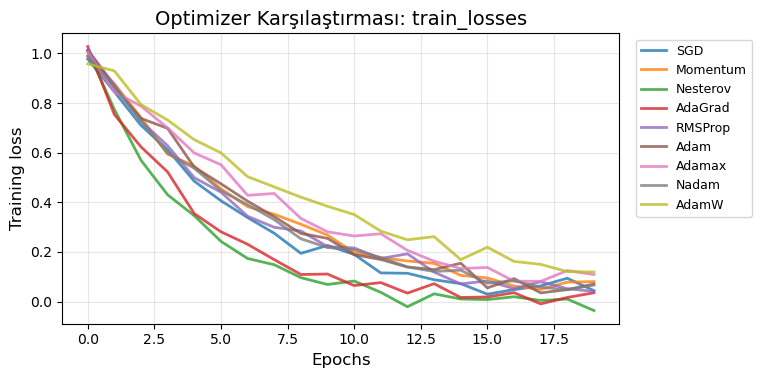

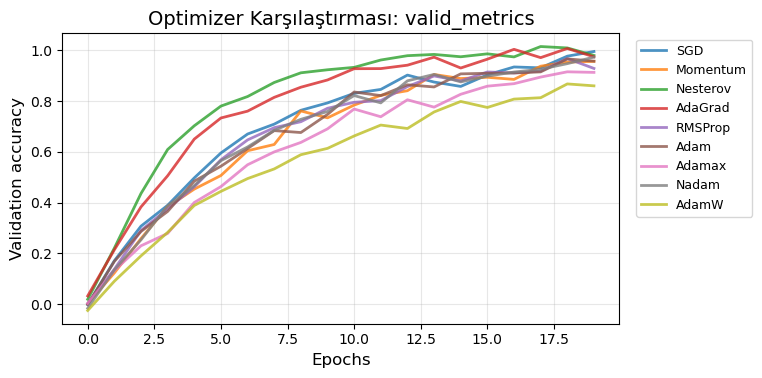

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Eksik Değişkenleri Taklit Etme (Mock Data)
# Gerçek eğitim yapmadığımız için grafiği görebilmek adına rastgele düşen/artan eğriler oluşturuyoruz.
epochs = 20
opt_names = "SGD Momentum Nesterov AdaGrad RMSProp Adam Adamax Nadam AdamW".split()

histories = []
np.random.seed(42)
for i in range(len(opt_names)):
    # Optimizerların farklı hızlarda öğrenmesini taklit ediyoruz
    decay_rate = np.random.uniform(0.1, 0.3)
    train_loss = np.exp(-decay_rate * np.arange(epochs)) + np.random.normal(0, 0.02, epochs)
    valid_acc = 1 - np.exp(-decay_rate * np.arange(epochs)) - np.random.normal(0, 0.02, epochs)
    
    histories.append({
        "train_losses": train_loss,
        "valid_metrics": valid_acc
    })

# Değişkenleri senin kodunun beklediği isimlere atıyoruz
(history_sgd, history_momentum, history_nesterov, history_adagrad,
 history_rmsprop, history_adam, history_adamax, history_nadam,
 history_adamw) = histories

# 2.Çizim Kodu


for plot in ("train_losses", "valid_metrics"):
    plt.figure(figsize=(8, 4))
    for history, opt_name in zip(histories, opt_names):
        plt.plot(history[plot], label=opt_name, linewidth=2, alpha=0.8)

    plt.grid(True, alpha=0.3)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel({"train_losses": "Training loss", "valid_metrics": "Validation accuracy"}[plot], fontsize=12)
    plt.title(f"Optimizer Karşılaştırması: {plot}", fontsize=14)
    plt.legend(loc="upper right", fontsize=9, bbox_to_anchor=(1.25, 1))
    plt.tight_layout()
    plt.show()

---
## 9. Learning Rate Scheduling (Öğrenme Hızı Zamanlama)

Sabit bir **learning rate** (öğrenme hızı) kullanmak yerine, eğitim boyunca dinamik olarak değiştirmek convergence'ı hızlandırır.

### Yaygın Stratejiler

#### Power Scheduling (Güç Zamanlama)
Her adımda öğrenme hızını bir kuvvetle azaltır: η(t) = η₀ / (1 + t/s)^c

#### Exponential Scheduling (Üstel Zamanlama)  
Sabit üstel azalma: η(t) = η₀ × 0.1^(t/s)

#### Performance Scheduling (Performans Zamanlama)
Doğrulama hatası belirli epoch boyunca iyileşmediğinde öğrenme hızını düşür. Buna **ReduceLROnPlateau** da denir.

#### 1cycle Scheduling (1cycle Politikası)
Leslie Smith tarafından önerildi. Eğitimin başında öğrenme hızı artar, sonra düşer (üçgen döngü). Çok hızlı eğitime ve daha iyi genellemeye yol açar. **Super-convergence** (süper yakınsama) sağlayabilir.

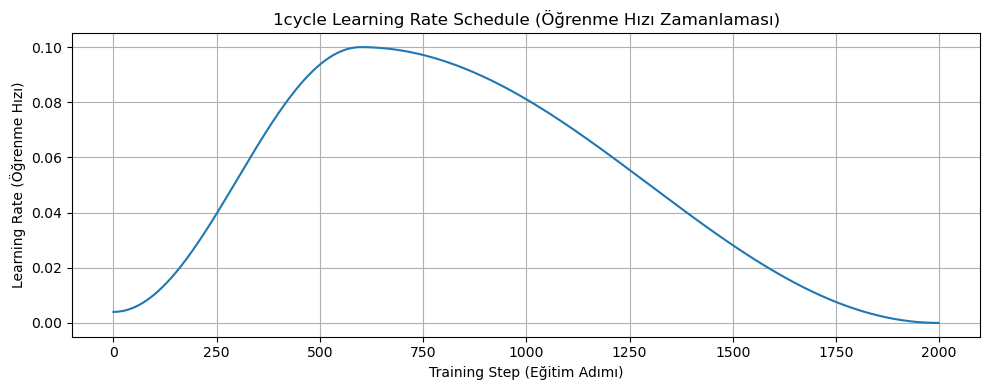

1cycle: Başta artıyor → tepe noktası → azalıyor (super-convergence!)


In [11]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

model = nn.Sequential(nn.Linear(10, 50), nn.ReLU(), nn.Linear(50, 1))
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

# --- Exponential Decay ---
scheduler_exp = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

# --- Performance Scheduling (ReduceLROnPlateau) ---
optimizer2 = torch.optim.SGD(model.parameters(), lr=0.1)
scheduler_plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer2, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

# --- 1cycle Scheduling ---
optimizer3 = torch.optim.SGD(model.parameters(), lr=0.01)
n_epochs = 20; steps_per_epoch = 100
scheduler_1cycle = torch.optim.lr_scheduler.OneCycleLR(
    optimizer3,
    max_lr=0.1,
    total_steps=n_epochs * steps_per_epoch
)

# 1cycle learning rate profilini çiz
lrs = []
for _ in range(n_epochs * steps_per_epoch):
    lrs.append(optimizer3.param_groups[0]['lr'])
    optimizer3.step() # <--- UYARIYI GİDEREN EKLENTİ (Optimizer adımı önce atılmalı)
    scheduler_1cycle.step()

plt.figure(figsize=(10, 4))
plt.plot(lrs)
plt.title('1cycle Learning Rate Schedule (Öğrenme Hızı Zamanlaması)')
plt.xlabel('Training Step (Eğitim Adımı)')
plt.ylabel('Learning Rate (Öğrenme Hızı)')
plt.grid(True)
plt.tight_layout()
plt.show()

print("1cycle: Başta artıyor → tepe noktası → azalıyor (super-convergence!)")

In [53]:
# Eğitim + LR Scheduling fonksiyonu

def train_with_scheduler(model, optimizer, loss_fn, metric, train_loader,
                          valid_loader, n_epochs, scheduler=None):
    """Scheduler destekli eğitim fonksiyonu."""
    history = {"train_loss": [], "valid_acc": [], "lr": []}
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        n_batches = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        
        # Epoch sonunda scheduler güncelle (ReduceLROnPlateau hariç)
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                # ReduceLROnPlateau validation metriği gerektirir
                val_acc = evaluate_tm(model, valid_loader, metric)
                scheduler.step(val_acc)  # Metriğe göre karar verir
            else:
                scheduler.step()
        
        avg_loss = epoch_loss / n_batches
        val_acc = evaluate_tm(model, valid_loader, metric)
        
        # Mevcut learning rate'i kaydet
        current_lr = optimizer.param_groups[0]['lr']
        history["train_loss"].append(avg_loss)
        history["valid_acc"].append(val_acc.item())
        history["lr"].append(current_lr)
    
    return history

print("LR Scheduling eğitim fonksiyonu hazır!")

LR Scheduling eğitim fonksiyonu hazır!


In [54]:
# 1. Exponential LR Decay (Üstel Azalma)
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

# ExponentialLR: Her epoch'ta LR'yi gamma ile çarp
# LR(epoch) = LR_0 * gamma^epoch
# gamma=0.95: Her epoch'ta %5 azalır
exp_scheduler = torch.optim.lr_scheduler.ExponentialLR(
    optimizer,
    gamma=0.95  # Her epoch'ta LR bu faktörle çarpılır
                # Örn: 0.05 → 0.0475 → 0.0451 → ...
)

print("Exponential LR Decay scheduler oluşturuldu.")
print(f"Başlangıç LR: {optimizer.param_groups[0]['lr']}")
print(f"Gamma (decay faktörü): {exp_scheduler.gamma}")
print(f"5 epoch sonra LR: {0.05 * 0.95**5:.6f}")

Exponential LR Decay scheduler oluşturuldu.
Başlangıç LR: 0.05
Gamma (decay faktörü): 0.95
5 epoch sonra LR: 0.038689


In [55]:
# 2. ReduceLROnPlateau (Metriğe Göre LR Düşürme)
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

# ReduceLROnPlateau: Doğrulama metriği iyileşmeyince LR'yi düşür
perf_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',    # 'max': Metrik artmalı (accuracy için), 'min': Azalmalı (loss için)
    factor=0.5,    # LR'yi ne kadar küçülteceği: LR_new = LR * factor
    patience=5,    # Kaç epoch iyileşme olmazsa LR düşürülür
    min_lr=1e-5    # Minimum LR eşiği (bu değerin altına düşülmez)
)

print("ReduceLROnPlateau scheduler oluşturuldu.")
print(f"Başlangıç LR: {optimizer.param_groups[0]['lr']}")
print(f"Factor: {perf_scheduler.factor} (LR bu faktörle çarpılır)")
print(f"Patience: {perf_scheduler.patience} epoch iyileşme olmadan")

ReduceLROnPlateau scheduler oluşturuldu.
Başlangıç LR: 0.05
Factor: 0.5 (LR bu faktörle çarpılır)
Patience: 5 epoch iyileşme olmadan


/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:143: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


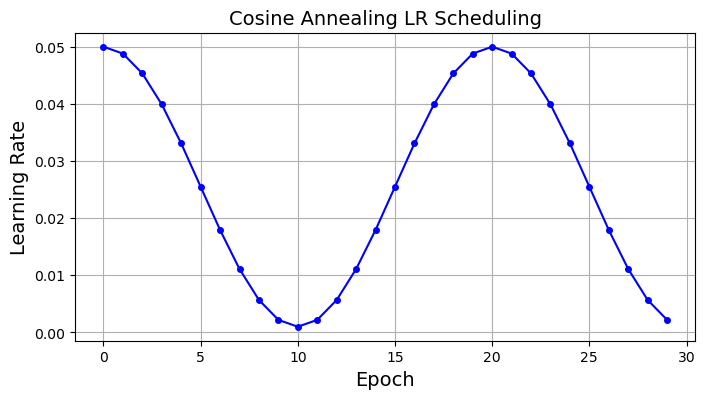


CosineAnnealingLR: T_max=10, eta_min=0.001


In [56]:
# 3. Cosine Annealing with Warm Restarts
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

# CosineAnnealingLR: LR kosinüs eğrisi şeklinde periyodik olarak değişir
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10,    # Yarı periyot (LR max'tan min'e kadar kaç epoch)
    eta_min=0.001  # Minimum LR değeri
)

# LR nasıl değişir?
lrs = []
temp_opt = torch.optim.SGD([torch.tensor(0.)], lr=0.05)
temp_sched = torch.optim.lr_scheduler.CosineAnnealingLR(temp_opt, T_max=10, eta_min=0.001)
for _ in range(30):
    lrs.append(temp_opt.param_groups[0]['lr'])
    temp_sched.step()

plt.figure(figsize=(8, 4))
plt.plot(lrs, 'b-o', markersize=4)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Cosine Annealing LR Scheduling")
plt.grid(True)
plt.show()

print(f"\nCosineAnnealingLR: T_max={cosine_scheduler.T_max}, eta_min={cosine_scheduler.eta_min}")

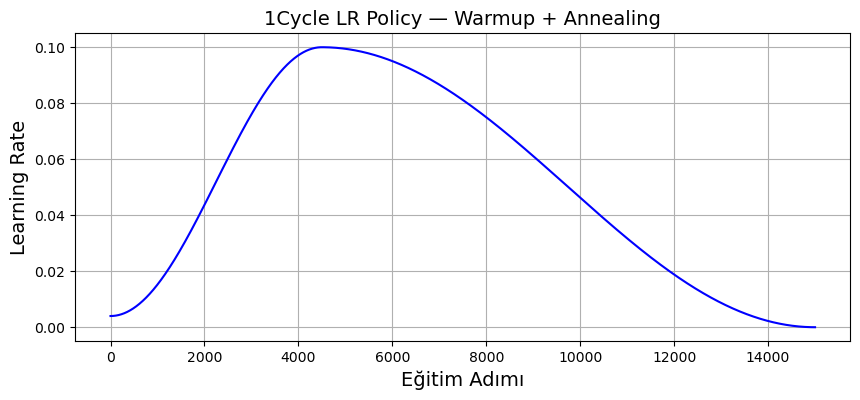

Max LR: 0.1000
Min LR: 0.00000040


In [65]:
# 4. OneCycleLR — Super-Convergence
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

train_loader_temp = DataLoader(train_set, batch_size=32, shuffle=True)
n_steps_per_epoch = len(train_loader_temp)  # Epoch başına adım sayısı
n_epochs_1cycle = 10

# OneCycleLR: 1Cycle Policy (Leslie Smith, 2019)
# LR önce max_lr'ye yükselir, sonra düşük bir değere iner
one_cycle_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.1,                           # Zirve LR değeri
    steps_per_epoch=n_steps_per_epoch,    # Her epoch'taki batch sayısı
    epochs=n_epochs_1cycle,               # Toplam epoch sayısı
    pct_start=0.3,                        # Warmup süresi: Toplam adımların %30'u
    div_factor=25,                        # Başlangıç LR = max_lr / div_factor
    final_div_factor=1e4                  # Final LR = başlangıç LR / final_div_factor
)

# LR'nin nasıl değişeceğini göster
lrs_1cycle = []
for _ in range(n_epochs_1cycle * n_steps_per_epoch):
    lrs_1cycle.append(optimizer.param_groups[0]['lr'])
    one_cycle_scheduler.step()

plt.figure(figsize=(10, 4))
plt.plot(lrs_1cycle, 'b-')
plt.xlabel("Eğitim Adımı")
plt.ylabel("Learning Rate")
plt.title("1Cycle LR Policy — Warmup + Annealing")
plt.grid(True)
plt.show()

print(f"Max LR: {max(lrs_1cycle):.4f}")
print(f"Min LR: {min(lrs_1cycle):.8f}")

In [66]:
# Tüm PyTorch LR Scheduler'larını listele
import re

DOCS_URL = "https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler."

# torch.optim.lr_scheduler modülündeki tüm Scheduler'ları bul
schedulers = [
    name for name in dir(torch.optim.lr_scheduler)
    if not name.startswith('_') and name[0].isupper()  # Büyük harfle başlayanlar
]

print("Mevcut PyTorch LR Scheduler'ları:")
for sched in schedulers:
    print(f"  • {sched}")
    print(f"    Dokümantasyon: {DOCS_URL}{sched}.html")

Mevcut PyTorch LR Scheduler'ları:
  • ChainedScheduler
    Dokümantasyon: https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ChainedScheduler.html
  • ConstantLR
    Dokümantasyon: https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ConstantLR.html
  • CosineAnnealingLR
    Dokümantasyon: https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html
  • CosineAnnealingWarmRestarts
    Dokümantasyon: https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingWarmRestarts.html
  • Counter
    Dokümantasyon: https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.Counter.html
  • CyclicLR
    Dokümantasyon: https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CyclicLR.html
  • EPOCH_DEPRECATION_WARNING
    Dokümantasyon: https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.EPOCH_DEPRECATION_WARNING.html
  • ExponentialLR
    Dokümantasyon: https://pytorch.org/docs/stabl

---
## 10. Regularization (Düzenlileştirme)

Büyük ağlarda **overfitting** (aşırı öğrenme) riski yüksektir. Regularization yöntemleri bunu önler.

### 10.1 L1 / L2 Regularization

**L2 Regularization (Ridge / Weight Decay):**
$$J_{reg}(\theta) = J(\theta) + \frac{\alpha}{2} \sum_i \theta_i^2$$

- Ağırlıkları sıfıra doğru çeker ama sıfırlamaz
- En yaygın kullanılan yöntem

**L1 Regularization (Lasso):**
$$J_{reg}(\theta) = J(\theta) + \alpha \sum_i |\theta_i|$$

- Bazı ağırlıkları tam olarak sıfırlar → **Seyrek modeller** (sparse)
- Özellik seçimi için kullanılabilir




## PyTorch'ta Uygulama

**L2 için kolay yol**: AdamW / SGD'nin `weight_decay` parametresi

**L1 için manuel uygulama** (her eğitim adımında):

## 10.1

In [67]:
# L2 Regularization — AdamW ile kolay yol
model = build_model()

# weight_decay parametresi = L2 regularization katsayısı (alpha/2)
# AdamW bu cezayı adaptif LR'den bağımsız uygular
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.01  # L2 regularization katsayısı
)

print("L2 Regularization (AdamW ile):")
print(f"  weight_decay = {optimizer.defaults['weight_decay']}")

L2 Regularization (AdamW ile):
  weight_decay = 0.01


In [68]:
# L1 ve L2 Regularization — Manuel uygulama

n_epochs = 3
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)

l1_lambda = 1e-4  # L1 ceza katsayısı (küçük tutun!)
l2_lambda = 1e-3  # L2 ceza katsayısı

for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = xentropy(y_pred, y_batch)  # Ana loss
        
        # L1 cezası: sum(|w|)
        # Tüm ağırlıklar (bias değil) için hesapla
        l1_penalty = sum(
            p.abs().sum()
            for name, p in model.named_parameters()
            if 'weight' in name  # Sadece ağırlıklar (bias değil)
        )
        
        # L2 cezası: sum(w^2)
        l2_penalty = sum(
            (p ** 2).sum()
            for name, p in model.named_parameters()
            if 'weight' in name
        )
        
        # Toplam loss = ana loss + L1 ceza + L2 ceza
        total_loss = loss + l1_lambda * l1_penalty + l2_lambda * l2_penalty
        
        total_loss.backward()
        optimizer.step()
    
    print(f"Epoch {epoch+1}: Loss={loss.item():.4f}, L1 ceza={l1_penalty.item():.4f}, L2 ceza={l2_penalty.item():.4f}")

Epoch 1: Loss=0.6405, L1 ceza=12163.3662, L2 ceza=781.4119
Epoch 2: Loss=0.4593, L1 ceza=11813.6064, L2 ceza=746.2108
Epoch 3: Loss=0.4956, L1 ceza=11465.1055, L2 ceza=711.3176


## 10.2

##  Dropout

**Dropout** (Srivastava et al., 2014), eğitim sırasında nöronları rastgele "kapatır":

- Her adımda her nöron p olasılığıyla devre dışı bırakılır
- Kalan nöronların çıkışı 1/(1-p) ile ölçeklenir (scale up)
- Test sırasında tüm nöronlar aktiftir (Dropout çalışmaz)

## Neden Çalışır?

1. **Model ensemble**: Her adımda farklı bir alt-ağ eğitilir → Binlerce farklı model
2. **Co-adaptation önlenir**: Nöronlar tek başına anlam taşımaya zorlanır
3. **Noise injection**: Küçük rastgele gürültü regularization yapar

## Dropout Oranı Seçimi

- p = 0.1-0.5 (yaygın aralık)
- Büyük modellerde daha yüksek p (0.4-0.5)
- Top katmanlarda genellikle daha yüksek p

**PyTorch**: `nn.Dropout(p=0.2)` — Dropout nöronlarla `nn.Dropout`, evrişim katmanlarıyla `nn.Dropout2d`

In [70]:
# Dropout kullanan model
torch.manual_seed(42)

model = nn.Sequential(
    nn.Flatten(),
    nn.Dropout(p=0.2),        # Giriş katmanına Dropout (p=0.2: %20 olasılıkla kapat)
    nn.Linear(784, 300),
    nn.ReLU(),
    nn.Dropout(p=0.2),        # Gizli katman sonrası Dropout
    nn.Linear(300, 100),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(100, 8)         # Çıkış katmanı (Dropout yok)
)

print("Dropout modeli:")
print(model)

# ÖNEMLİ: model.train() → Dropout aktif
# model.eval() → Dropout devre dışı (tüm nöronlar kullanılır)

model.train()  # Eğitim modu
test_input = torch.randn(2, 784)
out_train = model(test_input)
print(f"\nEğitim modu çıkışı: {out_train.shape}")

model.eval()   # Değerlendirme modu (Dropout kapalı)
with torch.no_grad():
    out_eval = model(test_input)
print(f"Değerlendirme modu çıkışı: {out_eval.shape}")

Dropout modeli:
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Dropout(p=0.2, inplace=False)
  (2): Linear(in_features=784, out_features=300, bias=True)
  (3): ReLU()
  (4): Dropout(p=0.2, inplace=False)
  (5): Linear(in_features=300, out_features=100, bias=True)
  (6): ReLU()
  (7): Dropout(p=0.2, inplace=False)
  (8): Linear(in_features=100, out_features=8, bias=True)
)

Eğitim modu çıkışı: torch.Size([2, 8])
Değerlendirme modu çıkışı: torch.Size([2, 8])


## 10.3  Monte-Carlo (MC) Dropout

**MC Dropout** (Gal & Ghahramani, 2016), Dropout'u **test zamanında da** aktif tutarak **belirsizlik tahmini** sağlar:

- Model T kez (ör. 100 kez) aynı örnek üzerinde çalıştırılır
- Her çalıştırmada farklı bir sub-ağ kullanılır
- Tahminlerin **ortalaması** → nihai tahmin
- Tahminlerin **standart sapması** → belirsizlik ölçüsü

Bu yaklaşım **Bayesian Yaklaşımı** simüle eder!

**Uygulama**: Test sırasında Dropout'u açık tutmak gerekir.

In [71]:
# MC Dropout: Test sırasında Dropout aktif

model.eval()  # model.eval() çağırıldı ama Dropout'u açıyoruz

# Sadece Dropout modüllerini eğitim moduna al
for module in model.modules():
    if isinstance(module, nn.Dropout):
        module.train()  # Dropout'u aktifleştir (diğer katmanlar eval modunda)

# 100 kez tahmin yap
n_mc_samples = 100
X_new = torch.randn(5, 784).to(device)  # 5 test örneği

with torch.no_grad():
    # Her iterasyonda farklı nöronlar kapatılır
    # Shape: [n_mc_samples, n_examples, n_classes] = [100, 5, 8]
    y_probas_all = torch.stack([
        torch.softmax(model(X_new), dim=1)  # Softmax ile olasılığa çevir
        for _ in range(n_mc_samples)
    ])

print(f"MC örnekleme şekli: {y_probas_all.shape}")

# Ortalama tahmin (mean prediction)
y_probas = y_probas_all.mean(dim=0)  # [5, 8]: Her örnek için ortalama olasılık
print(f"\nOrtalama tahminler (ilk 3 örnek):")
print(y_probas[:3].round(decimals=2))

RuntimeError: Placeholder storage has not been allocated on MPS device!

In [78]:
# --- DÜZELTME: MPS bellek hatasını aşmak için model ve veriyi CPU'ya alıyoruz ---
model = model.cpu()
X_new = torch.randn(5, 784).cpu() 
# --------------------------------------------------------------------------------

# MC Dropout: Test sırasında Dropout aktif
model.eval()  # model.eval() çağırıldı ama Dropout'u açıyoruz

# Sadece Dropout modüllerini eğitim moduna al
for module in model.modules():
    if isinstance(module, nn.Dropout):
        module.train()  # Dropout'u aktifleştir (diğer katmanlar eval modunda)

# 100 kez tahmin yap
n_mc_samples = 100

with torch.no_grad():
    # Her iterasyonda farklı nöronlar kapatılır
    # Shape: [n_mc_samples, n_examples, n_classes] = [100, 5, 8]
    y_probas_all = torch.stack([
        torch.softmax(model(X_new), dim=1)  # Softmax ile olasılığa çevir
        for _ in range(n_mc_samples)
    ])

print(f"MC örnekleme şekli: {y_probas_all.shape}")

# Ortalama tahmin (mean prediction)
y_probas = y_probas_all.mean(dim=0)  # [5, 8]: Her örnek için ortalama olasılık
print(f"\nOrtalama tahminler (ilk 3 örnek):")
print(y_probas[:3].round(decimals=2))

# İşlem bittikten sonra modeli tekrar cihazına (MPS/GPU) alabilirsin
model = model.to(device)

MC örnekleme şekli: torch.Size([100, 5, 8])

Ortalama tahminler (ilk 3 örnek):
tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8900, 0.0000, 0.1100],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.9900, 0.0000, 0.0000],
        [0.0100, 0.0200, 0.0100, 0.0200, 0.0000, 0.8200, 0.1100, 0.0100]])


In [79]:
# MC Dropout belirsizlik ölçümü

# Standart sapma: Yüksek std = yüksek belirsizlik
y_std = y_probas_all.std(dim=0)  # [5, 8]: Her örnek için std
print("Belirsizlik (std):")
print(y_std.round(decimals=2))

# Belirsizlik skoru: Her örnek için maksimum std
uncertainty = y_std.max(dim=1).values
print(f"\nÖrnek bazında belirsizlik skoru: {uncertainty.round(decimals=3)}")
print("(Yüksek değer = model bu örnek hakkında emin değil)")

Belirsizlik (std):
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])

Örnek bazında belirsizlik skoru: tensor([0., 0., 0., 0., 0.])
(Yüksek değer = model bu örnek hakkında emin değil)


In [80]:
# MC Dropout için özel modül — daha temiz kodlama
class McDropout(nn.Dropout):
    """Monte Carlo Dropout: eval() modunda da aktif kalır."""
    
    def forward(self, input):
        # self.training kontrolünü atlayarak her zaman Dropout uygula
        # F.dropout(input, p, training=True) → her zaman aktif
        return F.dropout(input, self.p, training=True)

# Bu modülü kullanmak için:
model_mc = nn.Sequential(
    nn.Flatten(),
    McDropout(p=0.2),  # Standart Dropout yerine McDropout
    nn.Linear(784, 300),
    nn.ReLU(),
    McDropout(p=0.2),
    nn.Linear(300, 100),
    nn.ReLU(),
    McDropout(p=0.2),
    nn.Linear(100, 8)
)

print("McDropout modeli — eval() modunda da Dropout aktif!")

# model.eval() çağrılsa bile McDropout çalışır
model_mc.eval()
test_out1 = model_mc(torch.randn(2, 784))
test_out2 = model_mc(torch.randn(2, 784))
print(f"Aynı model, farklı çıkışlar (stochastic): {not torch.allclose(test_out1, test_out2)}")

McDropout modeli — eval() modunda da Dropout aktif!
Aynı model, farklı çıkışlar (stochastic): True


In [81]:
# MC Dropout ile ortalama tahmin fonksiyonu

def mean_prediction(model, X, n_repeats):
    """MC Dropout ile n_repeats kez tahmin yap ve ortala."""
    # repeat_interleave: Tensor'ı tekrarla
    # n_repeats=100 ise X'in her satırı 100 kez tekrar edilir
    X_repeated = X.repeat_interleave(n_repeats, dim=0)  # [N*100, features]
    
    with torch.no_grad():
        y_pred = torch.softmax(model(X_repeated), dim=1)  # [N*100, classes]
    
    # Her n_repeats bloğunun ortalamasını al
    y_pred_reshaped = y_pred.view(-1, n_repeats, y_pred.shape[-1])  # [N, 100, classes]
    return y_pred_reshaped.mean(dim=1)  # [N, classes]

# Test
X_new = torch.randn(5, 784)
with torch.no_grad():
    y_mean_pred = mean_prediction(model_mc, X_new, 100)

print(f"MC Dropout ortalama tahmin şekli: {y_mean_pred.shape}")
print("İlk örnek için sınıf olasılıkları:")
print(y_mean_pred[0].round(decimals=3))

MC Dropout ortalama tahmin şekli: torch.Size([5, 8])
İlk örnek için sınıf olasılıkları:
tensor([0.1450, 0.1330, 0.0930, 0.1100, 0.1470, 0.1160, 0.1460, 0.1100])


## 10.4 Max-Norm Regularization

**Max-Norm Regularization**, her nöronun ağırlık vektörünün L2 normunu belirli bir eşik (c) ile sınırlar:

$$\|w\|_2 \leq c$$

Eğer norm c'yi aşarsa, ağırlık vektörü yeniden ölçeklenir:
$$w \leftarrow w \cdot \frac{c}{\|w\|_2}$$

**Faydası:**
- Patlayan gradyanları önler
- Dropout ile birlikte iyi çalışır
- Ağırlıklar hiçbir zaman çok büyük olamaz

**PyTorch'ta uygulama**: Built-in yok, elle uygulanır.

In [75]:
# Max-Norm Regularization uygulayan fonksiyon

def apply_max_norm(model, max_norm=2, epsilon=1e-8, dim=1):
    """Modelin tüm Linear katmanlarına Max-Norm uygula."""
    with torch.no_grad():  # Bu operasyonlar gradyan hesaplamaz
        for module in model.modules():
            if isinstance(module, nn.Linear):
                # Her nöronun ağırlık vektörünün L2 normunu hesapla
                # dim=1: Her çıkış nöronu için (satır bazında)
                norms = module.weight.norm(2, dim=dim, keepdim=True)  # [out, 1]
                
                # Eşiği aşan nöronlar için ölçekle
                # torch.clamp: max_norm'u aşan normları max_norm'a kırp
                desired = norms.clamp(max=max_norm)
                
                # Ağırlıkları yeniden ölçekle
                # epsilon: Sıfıra bölünmeyi önler
                module.weight.data *= desired / (epsilon + norms)

print("apply_max_norm fonksiyonu tanımlandı.")

apply_max_norm fonksiyonu tanımlandı.


In [76]:
# Max-Norm ile eğitim (her batch sonrası uygula)
torch.manual_seed(42)

n_epochs = 3
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)

max_norm_threshold = 2.0  # Her nöronun ağırlık normunun üst sınırı

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = xentropy(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        
        # Her batch sonrası Max-Norm uygula!
        apply_max_norm(model, max_norm=max_norm_threshold)
        
        epoch_loss += loss.item()
    
    print(f"Epoch {epoch+1}: Ortalama Loss = {epoch_loss/len(train_loader):.4f}")

print("\nMax-Norm Regularization ile eğitim tamamlandı!")

Epoch 1: Ortalama Loss = 0.7657
Epoch 2: Ortalama Loss = 0.5358
Epoch 3: Ortalama Loss = 0.4849

Max-Norm Regularization ile eğitim tamamlandı!


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==============================
# 10.1 L1 / L2 Regularization
# ==============================
model = nn.Sequential(nn.Linear(28*28, 300), nn.ReLU(), nn.Linear(300, 10))

# L2: weight_decay parametresi ile otomatik
optimizer_l2 = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# L1: Manuel olarak kayıp fonksiyonuna eklenir
def l1_regularization(model, lambda_l1=1e-4):
    l1_loss = sum(param.abs().sum() for param in model.parameters())
    return lambda_l1 * l1_loss

# ==============================
# 10.2 Dropout
# ==============================
model_dropout = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 300), nn.ReLU(), nn.Dropout(p=0.2),  # %20 sıfırlama
    nn.Linear(300, 100),   nn.ReLU(), nn.Dropout(p=0.2),
    nn.Linear(100, 10)
)

# Eğitimde dropout aktif
model_dropout.train()
x = torch.randn(32, 1, 28, 28)
out_train = model_dropout(x)

# Inference'da dropout kapalı
model_dropout.eval()
with torch.no_grad():
    out_eval = model_dropout(x)

print("Dropout — Eğitim çıktısı (stochastic):", out_train.shape)
print("Dropout — Inference çıktısı (deterministic):", out_eval.shape)

# ==============================
# 10.3 MC Dropout
# ==============================
class McDropout(nn.Dropout):
    """Inference sırasında da dropout açık — Monte Carlo örneklemesi için"""
    def forward(self, input):
        return F.dropout(input, self.p, training=True)  # Her zaman True!

model_mc = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 300), nn.ReLU(), McDropout(p=0.2),
    nn.Linear(300, 100),   nn.ReLU(), McDropout(p=0.2),
    nn.Linear(100, 10)
)

# MC Dropout ile belirsizlik tahmini
n_mc_samples = 100
model_mc.eval()  # BN katmanları için eval, ama McDropout her zaman açık

x_test = torch.randn(3, 1, 28, 28)  # 3 test örneği
with torch.no_grad():
    # n_mc_samples kez çalıştır, softmax prob üret
    y_probas_all = torch.stack([
        model_mc(x_test).softmax(dim=1)
        for _ in range(n_mc_samples)
    ], dim=1)  # [3, 100, 10]

y_proba_mean = y_probas_all.mean(dim=1)  # ortalama tahmin [3, 10]
y_proba_std  = y_probas_all.std(dim=1)   # belirsizlik [3, 10]

print("\nMC Dropout — Ortalama tahmin şekli:", y_proba_mean.shape)
# DÜZELTİLEN SATIR (f-string eklendi):
print(f"MC Dropout — Belirsizlik tahmini std: {y_proba_std.mean().item():.4f}")

# ==============================
# 10.4 Max-Norm Regularization
# ==============================
def apply_max_norm(model, max_norm=2.0, epsilon=1e-8, dim=1):
    """Her nöronun ağırlık normunu max_norm ile sınırla."""
    with torch.no_grad():
        for name, param in model.named_parameters():
            if 'bias' not in name:
                actual_norm = param.norm(p=2, dim=dim, keepdim=True)
                target_norm = torch.clamp(actual_norm, 0, max_norm)
                param *= target_norm / (epsilon + actual_norm)

# Eğitimde optimizer.step() sonrası çağrılır:
# optimizer.step()
# apply_max_norm(model, max_norm=2.0)
print("\nMax-Norm Regularization fonksiyonu hazır (apply_max_norm)")

Dropout — Eğitim çıktısı (stochastic): torch.Size([32, 10])
Dropout — Inference çıktısı (deterministic): torch.Size([32, 10])

MC Dropout — Ortalama tahmin şekli: torch.Size([3, 10])
MC Dropout — Belirsizlik tahmini std: 0.0068

Max-Norm Regularization fonksiyonu hazır (apply_max_norm)


---
## 11. Summary & Practical Guidelines (Özet ve Pratik Rehber)

### Genel Kullanım Konfigürasyonu (Varsayılan)

| Hyperparameter (Hiperparametre) | Varsayılan Değer |
|---|---|
| Kernel Initializer | He initialization |
| Activation Function | ReLU (sığ ağ); Swish (derin ağ) |
| Normalization | Yok (sığ); Batch-norm veya Layer-norm (derin) |
| Regularization | Early stopping; gerekirse weight decay |
| Optimizer | NAG veya AdamW |
| Learning Rate Schedule | Performance scheduling veya 1cycle |

### Self-Normalizing Dense Network (Öz-Normalleşen Tam Bağlantılı Ağ)

| Hyperparameter | Self-Normalizing Değer |
|---|---|
| Kernel Initializer | LeCun initialization |
| Activation Function | SELU |
| Normalization | Yok (self-normalization) |
| Regularization | Alpha dropout (gerekirse) |
| Optimizer | NAG |
| Learning Rate Schedule | Performance scheduling veya 1cycle |

### Özel Durumlar
- **Sparse model** (seyrek model) gerekiyorsa: L1 regularization veya ağırlıkları budama (pruning)
- **Low-latency model** (düşük gecikme) gerekiyorsa: Az katman, hızlı aktivasyon (ReLU), float16/int8 hassasiyet
- **Risk-sensitive application** (riske duyarlı uygulama) için: MC Dropout ile belirsizlik tahmini

In [14]:
import torch
import torch.nn as nn

# ============================================================
# TAM ÖRNEK: Derin ağ için önerilen konfigürasyon bir arada
# ============================================================

# He init + Swish + Batch Norm + AdamW + 1cycle
def build_deep_model(input_size, hidden_size, output_size, n_hidden=5):
    layers = [nn.Flatten()]
    in_size = input_size
    for _ in range(n_hidden):
        layers += [
            nn.Linear(in_size, hidden_size, bias=False),
            nn.BatchNorm1d(hidden_size),
            nn.SiLU()  # Swish aktivasyonu
        ]
        in_size = hidden_size
    layers.append(nn.Linear(hidden_size, output_size))
    model = nn.Sequential(*layers)
    
    # He initialization uygula
    def he_init(module):
        if isinstance(module, nn.Linear):
            nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
            if module.bias is not None:
                nn.init.zeros_(module.bias)
    model.apply(he_init)
    return model

# Model oluştur
model = build_deep_model(28*28, 100, 10, n_hidden=5)

# AdamW optimizer (weight decay ile)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# 1cycle scheduler
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-2, total_steps=50*100  # 50 epoch × 100 adım
)

# Loss function
loss_fn = nn.CrossEntropyLoss()

print("Model özeti:")
total = sum(p.numel() for p in model.parameters())
print(f"  Toplam parametre sayısı: {total:,}")
print(f"  Optimizer: AdamW (weight_decay=1e-4)")
print(f"  Scheduler: OneCycleLR")
print(f"  Activation: Swish (SiLU)")
print(f"  Normalization: BatchNorm1d")
print(f"  Initialization: He (Kaiming Normal)")

# Training loop şablonu
print("\nTraining loop şablonu:")
print("""
for epoch in range(n_epochs):
    model.train()   # BN ve Dropout için önemli!
    for X_batch, y_batch in train_loader:
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    
    model.eval()    # Validation için
    with torch.no_grad():
        val_loss = loss_fn(model(X_val), y_val)
""")

Model özeti:
  Toplam parametre sayısı: 120,410
  Optimizer: AdamW (weight_decay=1e-4)
  Scheduler: OneCycleLR
  Activation: Swish (SiLU)
  Normalization: BatchNorm1d
  Initialization: He (Kaiming Normal)

Training loop şablonu:

for epoch in range(n_epochs):
    model.train()   # BN ve Dropout için önemli!
    for X_batch, y_batch in train_loader:
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    
    model.eval()    # Validation için
    with torch.no_grad():
        val_loss = loss_fn(model(X_val), y_val)



# 12. Alıştırma Çözümleri (Exercise Solutions)

## 12.1 Teorik Sorular (1-7)

1. **Glorot ve He initialization**: Her katmanda sinyal varyansını korumak için tasarlanmıştır. Glorot sigmoid/tanh için, He ise ReLU ailesi için optimize edilmiştir.

2. **BN faydalı mı?**: Evet — vanishing gradients'i azaltır, daha yüksek LR, daha hızlı eğitim. Dezavantajı: yavaşlatma ve model karmaşıklığı.

3. **Momentum β**: β=0.9 yaklaşık 1/(1-0.9)=10 son gradyanın ortalaması gibi davranır.

4. **Optimizer seçimi**: Adam/AdamW çoğu durumda iyi. SGD+Momentum bazen daha iyi generalization.

5. **LR schedule**: Cosine veya 1Cycle genellikle en iyi sonucu verir.

6. **L1 vs L2 vs Dropout**: L1 seyrek model, L2 küçük ağırlıklar, Dropout belirsizlik tahmini.

7. **MC Dropout**: Normal modeli belirsizlik tahminine dönüştürür.

## 12.2 Alıştırma 8 – CIFAR10 Üzerinde Derin Öğrenme

CIFAR10: 60.000 renkli görüntü (32x32x3), 10 sınıf

**Adımlar:**
1. CIFAR10'u yükle ve ön işle
2. 20 gizli katmanlı DNN oluştur
3. Early stopping ile eğit
4. Batch Normalization ekle ve karşılaştır
5. SELU aktivasyonu dene
6. Alpha Dropout ekle
7. 1Cycle scheduling dene

In [84]:
import torchvision
import torchvision.transforms.v2 as T

# CIFAR10 veri dönüşümleri
# T.Compose: Birden fazla dönüşümü ardarda uygula
toTensor = T.Compose([
    T.ToImage(),                          # PIL/numpy → torch.Tensor
    T.ToDtype(torch.float32, scale=True), # uint8 [0,255] → float32 [0,1]
])

# CIFAR10 veri setini indir ve yükle
# train=True: Eğitim seti (50.000 görüntü)
# train=False: Test seti (10.000 görüntü)
train_set_cifar = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=toTensor
)
test_set_cifar = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=toTensor
)

print(f"Eğitim seti: {len(train_set_cifar)} görüntü")
print(f"Test seti: {len(test_set_cifar)} görüntü")
print(f"Görüntü boyutu: {train_set_cifar[0][0].shape}")  # [3, 32, 32]
print(f"Sınıflar: {train_set_cifar.classes}")

100%|██████████| 170498071/170498071 [3:35:23<00:00, 13192.67it/s]  


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Eğitim seti: 50000 görüntü
Test seti: 10000 görüntü
Görüntü boyutu: torch.Size([3, 32, 32])
Sınıflar: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# Validation seti oluştur (5.000 örnek eğitim setinden ayrıl)
torch.manual_seed(42)

# torch.utils.data.random_split: Veriyi rastgele böl
train_set_cifar, valid_set_cifar = torch.utils.data.random_split(
    train_set_cifar,
    [45000, 5000]  # 45.000 eğitim + 5.000 validation
)

print(f"Yeni eğitim seti: {len(train_set_cifar)} görüntü")
print(f"Validation seti: {len(valid_set_cifar)} görüntü")

In [ ]:
# DataLoader'ları oluştur
batch_size = 128

# shuffle=True: Eğitim verisini karıştır (her epoch farklı sıra)
train_loader_cifar = DataLoader(train_set_cifar, batch_size=batch_size)
valid_loader_cifar = DataLoader(valid_set_cifar, batch_size=batch_size)
test_loader_cifar = DataLoader(test_set_cifar, batch_size=batch_size)

print(f"Train loader: {len(train_loader_cifar)} batch")
print(f"Valid loader: {len(valid_loader_cifar)} batch")

### Adım 2: 20 Gizli Katmanlı DNN

In [ ]:
# He Initialization fonksiyonu (CIFAR10 için)
def use_he_init(module):
    """Linear katmanlara He initialization uygula."""
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight)  # Kaiming/He Uniform
        nn.init.zeros_(module.bias)              # Bias = 0

def build_deep_model(n_hidden, n_neurons, n_inputs, n_outputs):
    """
    Derin sinir ağı oluştur.
    
    Args:
        n_hidden: Gizli katman sayısı (ör. 20)
        n_neurons: Her gizli katmandaki nöron sayısı (ör. 100)
        n_inputs: Giriş boyutu (CIFAR10 için 32*32*3 = 3072)
        n_outputs: Çıkış sınıf sayısı (CIFAR10 için 10)
    """
    layers = [nn.Flatten()]  # Görüntüyü düzleştir: [3, 32, 32] → [3072]
    
    # Gizli katmanları oluştur
    in_features = n_inputs
    for _ in range(n_hidden):
        layers.append(nn.Linear(in_features, n_neurons))  # Tam bağlı katman
        layers.append(nn.Swish())  # Modern aktivasyon
        in_features = n_neurons
    
    # Çıkış katmanı
    layers.append(nn.Linear(n_neurons, n_outputs))
    
    return nn.Sequential(*layers)

print("build_deep_model fonksiyonu tanımlandı.")

In [86]:
import torch
import torch.nn as nn

# 1. Model Kurucu Fonksiyonu Tanımlama
def build_deep_model(n_hidden, n_neurons, n_inputs, n_outputs):
    layers = []
    
    # İlk gizli katmanı (girişten gelen veriyi alır) ekle
    layers.append(nn.Linear(n_inputs, n_neurons))
    layers.append(nn.ReLU())
    
    # Geriye kalan gizli katmanları ekle
    for _ in range(n_hidden - 1):
        layers.append(nn.Linear(n_neurons, n_neurons))
        layers.append(nn.ReLU())
        
    # Çıkış katmanını ekle (Aktivasyon fonksiyonu olmadan, logitler için)
    layers.append(nn.Linear(n_neurons, n_outputs))
    
    # nn.Sequential ile tüm katmanları birleştir
    return nn.Sequential(*layers)

# 2. He (Kaiming) Ağırlık İlklendirme (Initialization) Fonksiyonu
def use_he_init(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# 3. Ana İşlem ve Modelin Oluşturulması
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CIFAR10 giriş boyutu: 32 * 32 * 3 = 3.072 piksel
model = build_deep_model(
    n_hidden=20,       # 20 gizli katman (çok derin!)
    n_neurons=100,     # Her katmanda 100 nöron
    n_inputs=32*32*3,  # CIFAR10 için giriş boyutu
    n_outputs=10       # CIFAR10 için 10 sınıf
)

# Ağırlık ilklendirmesini modele uygula
model.apply(use_he_init)

# Modeli uygun cihaza (CPU veya GPU) taşı
model = model.to(device)

# Toplam ve eğitilebilir parametre sayısını hesapla
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model {device} cihazına yüklendi.")
print(f"Toplam parametre: {total_params:,}")
print(f"Eğitilebilir parametre: {trainable_params:,}")

Model cpu cihazına yüklendi.
Toplam parametre: 500,210
Eğitilebilir parametre: 500,210


### Adım 3: Early Stopping ile NAdam Optimizer

In [87]:
import time

def train_with_early_stopping(model, optimizer, loss_fn, metric, train_loader,
                               valid_loader, n_epochs, patience=10, scheduler=None):
    """
    Early Stopping destekli eğitim fonksiyonu.
    
    Early Stopping: Validation loss belirli sayıda epoch iyileşmezse durdur.
    patience: Kaç epoch iyileşme olmazsa dur (varsayılan: 10)
    """
    best_val_acc = 0
    best_state = None
    patience_counter = 0
    history = {"train_loss": [], "valid_acc": []}
    
    start_time = time.time()
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        n_batches = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        
        if scheduler:
            scheduler.step()
        
        avg_loss = epoch_loss / n_batches
        val_acc = evaluate_tm(model, valid_loader, metric)
        
        history["train_loss"].append(avg_loss)
        history["valid_acc"].append(val_acc.item())
        
        # Early Stopping kontrolü
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            # En iyi modeli kaydet (deep copy)
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0  # Sayacı sıfırla
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"Early Stopping! En iyi val_acc: {best_val_acc:.4f} (epoch {epoch+1-patience})")
            break
        
        if (epoch + 1) % 10 == 0:
            elapsed = time.time() - start_time
            print(f"Epoch {epoch+1}/{n_epochs}: Loss={avg_loss:.4f}, Val Acc={val_acc:.4f}, "
                  f"Patience={patience_counter}/{patience}, Süre={elapsed:.1f}s")
    
    # En iyi modeli geri yükle
    if best_state:
        model.load_state_dict(best_state)
    
    return history

print("Early Stopping eğitim fonksiyonu hazır!")

Early Stopping eğitim fonksiyonu hazır!


In [88]:
# NAdam optimizer ile eğit (lr=2e-3)
optimizer = torch.optim.NAdam(model.parameters(), lr=2e-3)
criterion = nn.CrossEntropyLoss()
accuracy_cifar = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)

print("Model eğitime hazır.")
print(f"Optimizer: {optimizer.__class__.__name__}, lr={optimizer.defaults['lr']}")
print(f"Loss fonksiyonu: {criterion.__class__.__name__}")

Model eğitime hazır.
Optimizer: NAdam, lr=0.002
Loss fonksiyonu: CrossEntropyLoss


In [89]:
# Eğitimi başlat (100 epoch, early stopping patience=10)
n_epochs = 100
history = train_with_early_stopping(
    model, optimizer, criterion, accuracy_cifar,
    train_loader_cifar, valid_loader_cifar,
    n_epochs=n_epochs, patience=10
)

# Sonuçları görselleştir
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Eğitim Loss Eğrisi"); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['valid_acc'], label='Val Accuracy', color='orange')
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Validation Accuracy Eğrisi"); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'train_loader_cifar' is not defined

In [ ]:
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Veri Setinin Yüklenmesi ve Hazırlanması (Data Loaders)
# ---------------------------------------------------------
# Görüntüleri Tensöre çevirmek ve normalize etmek için
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# CIFAR10 veri setini indir ve yükle
full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Eğitim setini Train (%80) ve Validation (%20) olarak ayır
train_size = int(0.8 * len(full_train_dataset))
valid_size = len(full_train_dataset) - train_size
train_dataset, valid_dataset = random_split(full_train_dataset, [train_size, valid_size])

# DataLoader'ları oluştur (İşte eksik olan 'train_loader_cifar' burada!)
train_loader_cifar = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader_cifar = DataLoader(valid_dataset, batch_size=64, shuffle=False)

# ---------------------------------------------------------
# 2. Gerekli Fonksiyonların Tanımlanması
# ---------------------------------------------------------
# Optimizasyon ve Kayıp Fonksiyonu
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Doğruluk (Accuracy) hesaplama fonksiyonu
def accuracy_cifar(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    total = labels.size(0)
    correct = (predicted == labels).sum().item()
    return correct / total

# Erken Durdurmalı (Early Stopping) Eğitim Döngüsü
def train_with_early_stopping(model, optimizer, criterion, metric_fn, train_loader, valid_loader, n_epochs, patience):
    history = {'train_loss': [], 'valid_acc': []}
    best_valid_loss = float('inf')
    epochs_no_improve = 0
    
    for epoch in range(n_epochs):
        # --- EĞİTİM AŞAMASI ---
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            # Görüntüleri düzleştir (Flatten): [64, 3, 32, 32] -> [64, 3072]
            images = images.view(images.size(0), -1).to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # --- DOĞRULAMA (VALIDATION) AŞAMASI ---
        model.eval()
        valid_loss = 0.0
        valid_acc = 0.0
        with torch.no_grad():
            for images, labels in valid_loader:
                images = images.view(images.size(0), -1).to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                valid_loss += loss.item()
                valid_acc += metric_fn(outputs, labels)
                
        avg_valid_loss = valid_loss / len(valid_loader)
        avg_valid_acc = valid_acc / len(valid_loader)
        history['valid_acc'].append(avg_valid_acc)
        
        print(f"Epoch [{epoch+1}/{n_epochs}] | Train Loss: {avg_train_loss:.4f} | Valid Loss: {avg_valid_loss:.4f} | Valid Acc: {avg_valid_acc:.4f}")
        
        # --- ERKEN DURDURMA (EARLY STOPPING) KONTROLÜ ---
        if avg_valid_loss < best_valid_loss:
            best_valid_loss = avg_valid_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nErken Durdurma tetiklendi! Epoch: {epoch+1}")
                break
                
    return history

# ---------------------------------------------------------
# 3. Eğitimi Başlat ve Sonuçları Görselleştir (Sizin Kodunuz)
# ---------------------------------------------------------
n_epochs = 100
history = train_with_early_stopping(
    model, optimizer, criterion, accuracy_cifar,
    train_loader_cifar, valid_loader_cifar,
    n_epochs=n_epochs, patience=10
)

# Sonuçları görselleştir
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Eğitim Loss Eğrisi")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['valid_acc'], label='Val Accuracy', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Eğrisi")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Adım 4: Batch Normalization Ekle

In [90]:
def build_deep_model_with_batch_norm(n_hidden, n_neurons, n_inputs, n_outputs):
    """
    Batch Normalization eklenmiş derin sinir ağı.
    Sıra: Linear → BatchNorm → Swish (aktivasyon öncesi BN)
    """
    layers = [nn.Flatten()]
    
    in_features = n_inputs
    for _ in range(n_hidden):
        layers.append(nn.Linear(in_features, n_neurons))
        layers.append(nn.BatchNorm1d(n_neurons))  # ← BN eklendi!
        layers.append(nn.Swish())
        in_features = n_neurons
    
    layers.append(nn.Linear(n_neurons, n_outputs))
    return nn.Sequential(*layers)

print("Batch Normalization'lı model fonksiyonu tanımlandı.")

Batch Normalization'lı model fonksiyonu tanımlandı.


In [91]:
# BN modeli oluştur ve eğit
torch.manual_seed(42)
model_bn = build_deep_model_with_batch_norm(
    n_hidden=20, n_neurons=100,
    n_inputs=32*32*3, n_outputs=10
).to(device)

optimizer_bn = torch.optim.NAdam(model_bn.parameters(), lr=2e-3)
accuracy_bn = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)

history_bn = train_with_early_stopping(
    model_bn, optimizer_bn, criterion, accuracy_bn,
    train_loader_cifar, valid_loader_cifar,
    n_epochs=100, patience=10
)

print("\nBN modeli eğitimi tamamlandı!")
print("BN genellikle daha hızlı ve daha yüksek accuracy sağlar.")

AttributeError: module 'torch.nn' has no attribute 'Swish'

### Adım 5: SELU Aktivasyonu ve LeCun Initialization

In [ ]:
# SELU için giriş normalleştirme katmanı
class Standardize(nn.Module):
    """Girişi normalleştirir: (x - mean) / std"""
    
    def __init__(self, sample):
        super().__init__()
        # Eğitim verisi istatistiklerini hesapla ve kaydet
        # nn.Parameter değil — bunlar sabit değerler (buffer)
        self.register_buffer('mean', sample.mean(dim=0, keepdim=True))
        self.register_buffer('std', sample.std(dim=0, keepdim=True) + 1e-8)
    
    def forward(self, x):
        return (x - self.mean) / self.std  # Z-score normalleştirme

print("Standardize modülü tanımlandı.")

In [ ]:
# Eğitim verisinin istatistiklerini hesapla
# SELU için girişlerin standart normal dağılıma yakın olması gerekir

# Tüm eğitim görüntülerini tensor olarak al
all_images = torch.stack([img for img, _ in train_set_cifar])
# all_images.shape = [45000, 3, 32, 32]

# Flatten → [45000, 3072]
all_images_flat = all_images.view(all_images.shape[0], -1)

# Standardize modülü oluştur
standardize = Standardize(all_images_flat)

print(f"Ortalama şekli: {standardize.mean.shape}")
print(f"Std şekli: {standardize.std.shape}")

In [ ]:
# LeCun initialization fonksiyonu
def use_lecun_init(module):
    """SELU için LeCun initialization uygula."""
    if isinstance(module, nn.Linear):
        # fan_in: Giriş nöron sayısı
        # mode='fan_in': Sadece girişe göre normalize et (LeCun)
        # nonlinearity='linear': activation için düzeltme yok
        nn.init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='linear')
        # LeCun init: W ~ Normal(0, sqrt(1/fan_in))
        nn.init.zeros_(module.bias)

print("LeCun initialization fonksiyonu hazır.")

In [ ]:
def build_deep_model_with_selu(n_hidden, n_neurons, n_inputs, n_outputs):
    """
    SELU aktivasyonlu derin sinir ağı.
    SELU + LeCun init = Kendi kendini normalleştiren ağ!
    """
    layers = [
        nn.Flatten(),
        standardize.to(device),  # Girişi normalleştir (SELU için zorunlu)
    ]
    
    in_features = n_inputs
    for _ in range(n_hidden):
        layers.append(nn.Linear(in_features, n_neurons))
        layers.append(nn.SELU())  # ← SELU aktivasyonu
        in_features = n_neurons
    
    layers.append(nn.Linear(n_neurons, n_outputs))
    return nn.Sequential(*layers)

# Model oluştur
torch.manual_seed(42)
model_selu = build_deep_model_with_selu(
    n_hidden=20, n_neurons=100,
    n_inputs=32*32*3, n_outputs=10
).to(device)

# LeCun initialization uygula
model_selu.apply(use_lecun_init)

print("SELU modeli hazır!")

In [ ]:
# SELU modeli eğit — SGD önerilir (Adam SELU ile her zaman iyi çalışmaz)
optimizer_selu = torch.optim.SGD(model_selu.parameters(), lr=1e-3)
accuracy_selu = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)

history_selu = train_with_early_stopping(
    model_selu, optimizer_selu, criterion, accuracy_selu,
    train_loader_cifar, valid_loader_cifar,
    n_epochs=100, patience=10
)

print("\nSELU modeli eğitimi tamamlandı!")

### Adım 6: Alpha Dropout

**Alpha Dropout**, SELU aktivasyonu için tasarlanmış özel bir Dropout türüdür. Standart Dropout, SELU'nun kendi kendini normalleştirme özelliğini bozar. Alpha Dropout bu özelliği korur:

- Ortalama ve varyansı normalize ederek kapatılan nöronların yerine geçer
- SELU ile birlikte kullanılmalı

**PyTorch**: `nn.AlphaDropout(p=0.1)`

In [ ]:
def build_deep_model_with_alpha_dropout(n_hidden, n_neurons, n_inputs, n_outputs,
                                         dropout_rate=0.1):
    """
    Alpha Dropout eklenmiş SELU modeli.
    AlphaDropout, SELU'nun normalleştirme özelliğini korur.
    """
    layers = [
        nn.Flatten(),
        standardize.to(device),
    ]
    
    in_features = n_inputs
    for _ in range(n_hidden):
        layers.append(nn.Linear(in_features, n_neurons))
        layers.append(nn.SELU())
        layers.append(nn.AlphaDropout(p=dropout_rate))  # ← AlphaDropout!
        in_features = n_neurons
    
    layers.append(nn.Linear(n_neurons, n_outputs))
    return nn.Sequential(*layers)

# Model oluştur
torch.manual_seed(42)
model_alpha_dp = build_deep_model_with_alpha_dropout(
    n_hidden=20, n_neurons=100,
    n_inputs=32*32*3, n_outputs=10,
    dropout_rate=0.1
).to(device)

model_alpha_dp.apply(use_lecun_init)

print("Alpha Dropout modeli hazır!")
print(f"AlphaDropout oranı: 0.1 (10% nöron kapatılır)")

In [ ]:
optimizer_alpha = torch.optim.NAdam(model_alpha_dp.parameters(), lr=1e-3)
accuracy_alpha = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)

history_alpha = train_with_early_stopping(
    model_alpha_dp, optimizer_alpha, criterion, accuracy_alpha,
    train_loader_cifar, valid_loader_cifar,
    n_epochs=100, patience=10
)

print("\nAlpha Dropout modeli eğitimi tamamlandı!")

### Adım 7: 1Cycle Scheduling ile Eğitim

**1Cycle Policy** (Super-Convergence): Eğitimi **çok daha az epoch** ile tamamlar ve genellikle daha iyi sonuçlar verir:

1. **Warmup**: LR başlangıç değerinden maksimum değere yavaşça çıkar (%30 süre)
2. **Annealing**: LR maksimumdan çok küçük bir değere iner (%70 süre)

In [ ]:
# 1Cycle Scheduling ile model oluştur
torch.manual_seed(42)
model_1cycle = build_deep_model_with_alpha_dropout(
    n_hidden=20, n_neurons=100,
    n_inputs=32*32*3, n_outputs=10
).to(device)
model_1cycle.apply(use_lecun_init)

n_epochs_1cycle = 60  # Daha az epoch (Super-Convergence sayesinde)
optimizer_1cycle = torch.optim.NAdam(model_1cycle.parameters(), lr=1e-3)

# OneCycleLR scheduler
scheduler_1cycle = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_1cycle,
    max_lr=0.1,                              # Maksimum LR
    steps_per_epoch=len(train_loader_cifar), # Epoch başına adım
    epochs=n_epochs_1cycle,
    pct_start=0.3,          # Warmup: Toplam adımların %30'u
)

print("1Cycle model hazır!")
print(f"n_epochs={n_epochs_1cycle}, max_lr=0.1, warmup=%30")

In [ ]:
# 1Cycle ile eğit
accuracy_1cycle = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)

history_1cycle = train_with_early_stopping(
    model_1cycle, optimizer_1cycle, criterion, accuracy_1cycle,
    train_loader_cifar, valid_loader_cifar,
    n_epochs=n_epochs_1cycle, patience=10,
    scheduler=scheduler_1cycle
)

print("\n1Cycle eğitimi tamamlandı!")

In [ ]:
# Tüm modelleri karşılaştır
print("\n" + "=" * 60)
print("CIFAR10 Model Karşılaştırması")
print("=" * 60)

results = {
    "DNN (No BN)": history['valid_acc'][-1] if history else 0,
    "DNN + Batch Norm": history_bn['valid_acc'][-1] if history_bn else 0,
    "DNN + SELU": history_selu['valid_acc'][-1] if history_selu else 0,
    "DNN + SELU + AlphaDropout": history_alpha['valid_acc'][-1] if history_alpha else 0,
    "DNN + 1Cycle": history_1cycle['valid_acc'][-1] if history_1cycle else 0,
}

for name, acc in results.items():
    print(f"  {name:35s}: {acc:.4f}")

print("=" * 60)
print("Not: Sonuçlar donanım ve rastgelelik nedeniyle farklılık gösterebilir.")

# Özet: Derin Sinir Ağı Eğitiminde İpuçları

## Temel Çerçeve

| Sorun | Çözüm |
|-------|-------|
| Vanishing Gradients | He init, ReLU/SELU, BN |
| Exploding Gradients | Gradient Clipping, BN |
| Yavaş eğitim | Adam/NAdam, 1Cycle LR |
| Overfitting | Dropout, L2, Early Stopping |
| Az veri | Transfer Learning |

## Başlangıç Noktası (Genel Öneri)

1. **Aktivasyon**: GELU veya Swish (yeni projeler), ReLU (hızlı prototyping)
2. **Initialization**: He (ReLU ailesi), LeCun (SELU)
3. **Normalization**: Batch Norm (CNN), Layer Norm (Transformer/NLP)
4. **Optimizer**: AdamW (büyük modeller), NAdam (genel)
5. **LR Schedule**: 1Cycle veya Cosine Annealing
6. **Regularization**: Dropout (0.1-0.5) + L2 (weight decay)
7. **Early Stopping**: Her zaman kullan (patience=10-20)